# Task 2 — Enhanced Strategy


## Overview And Research Purpose
This notebook documents the Task 2 enhanced commodity trend-following strategy. It runs the enhanced pipeline with multi-lookback conviction, optional macro modulation, execution-time short RSI cap, Parabolic SAR exits, conviction sizing, and transaction costs. SAR and cost diagnostics are training-only; final holdout evaluation belongs at the end after parameters are frozen.


## 0. Imports And Data Loading
Set up local imports, load training prices and returns, and load training-period macro inputs used for conviction modulation.


In [234]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath('')).parents[1]
sys.path.insert(0, str(ROOT))                         # tasks.task_1.* / tasks.task_2.* qualified imports
sys.path.insert(0, str(ROOT / 'tasks' / 'task_2'))   # strategy_enhanced, signals, portfolio
sys.path.insert(0, str(ROOT / 'tasks' / 'task_1'))   # indicators.py, strategy (baseline), analytics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.25

from strategy_enhanced import build_signals as build_signals_enh, run_strategy as run_strategy_enh
from diagnostics      import transaction_cost_sensitivity, sl_mult_grid_search, sar_grid_search
from strategy          import run_strategy  as run_strategy_base
from analytics         import (performance_stats, sector_contribution,
                                position_summary, plot_signals,
                                rolling_sharpe, plot_rolling_sharpe)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [235]:
prices = pd.read_csv(ROOT / 'data/training/close_prices_final.csv',
                     index_col=0, parse_dates=True).sort_index()

returns = prices.pct_change()
assets  = pd.read_csv(ROOT / 'data/raw/assets.csv')
factor  = returns.mean(axis=1)
factor.name = 'EW Factor'

print(f'Period      : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Commodities : {prices.shape[1]}')
print(f'Days        : {len(prices):,}')


Period      : 2005-10-05 → 2019-12-31
Commodities : 23
Days        : 3,715


In [236]:
# ── Load external macro data (aligned to training period) ──────────────────
ext_dir = ROOT / 'data/external/training'

fx_spot  = pd.read_csv(ext_dir / 'fx_spot_levels.csv',
                       index_col=0, parse_dates=True).sort_index()
equity   = pd.read_csv(ext_dir / 'equity_indices_levels.csv',
                       index_col=0, parse_dates=True).sort_index()
credit   = pd.read_csv(ext_dir / 'credit_spreads_levels.csv',
                       index_col=0, parse_dates=True).sort_index()
fx_vol   = pd.read_csv(ext_dir / 'atm_vols_levels.csv',
                       index_col=0, parse_dates=True).sort_index()

external = {'fx_spot': fx_spot, 'equity': equity, 'credit': credit, 'fx_vol': fx_vol}

print(f'FX spot    : {fx_spot.shape}   cols: {list(fx_spot.columns[:4])}...')
print(f'Equity     : {equity.shape}    cols: {list(equity.columns[:4])}')
print(f'Credit     : {credit.shape}    cols: {list(credit.columns)}')
print(f'FX vol     : {fx_vol.shape}    cols: {list(fx_vol.columns[:4])}...')


FX spot    : (3715, 15)   cols: ['EURUSD CURNCY', 'GBPUSD Curncy', 'USDJPY Curncy', 'AUDUSD Curncy']...
Equity     : (3715, 9)    cols: ['SPX INDEX', 'NKY INDEX', 'UKX INDEX', 'SX5E INDEX']
Credit     : (3715, 4)    cols: ['CDX IG CDSI GEN 5Y Corp', 'CDX HY CDSI GEN 5Y CORP', 'ITRX EUR CDSI GEN 5Y CORP', 'ITRX XOVER CDSI GEN 5Y CORP']
FX vol     : (3715, 45)    cols: ['EURUSDV1M Curncy', 'EURUSDV3M Curncy', 'EURUSDV1Y Curncy', 'GBPUSDV1M Curncy']...


### 0.1 Macro Inputs And Signals
Build the dollar, equity, credit, and volatility diagnostics used by the enhanced strategy. These signals modulate conviction only; they do not change trade direction.


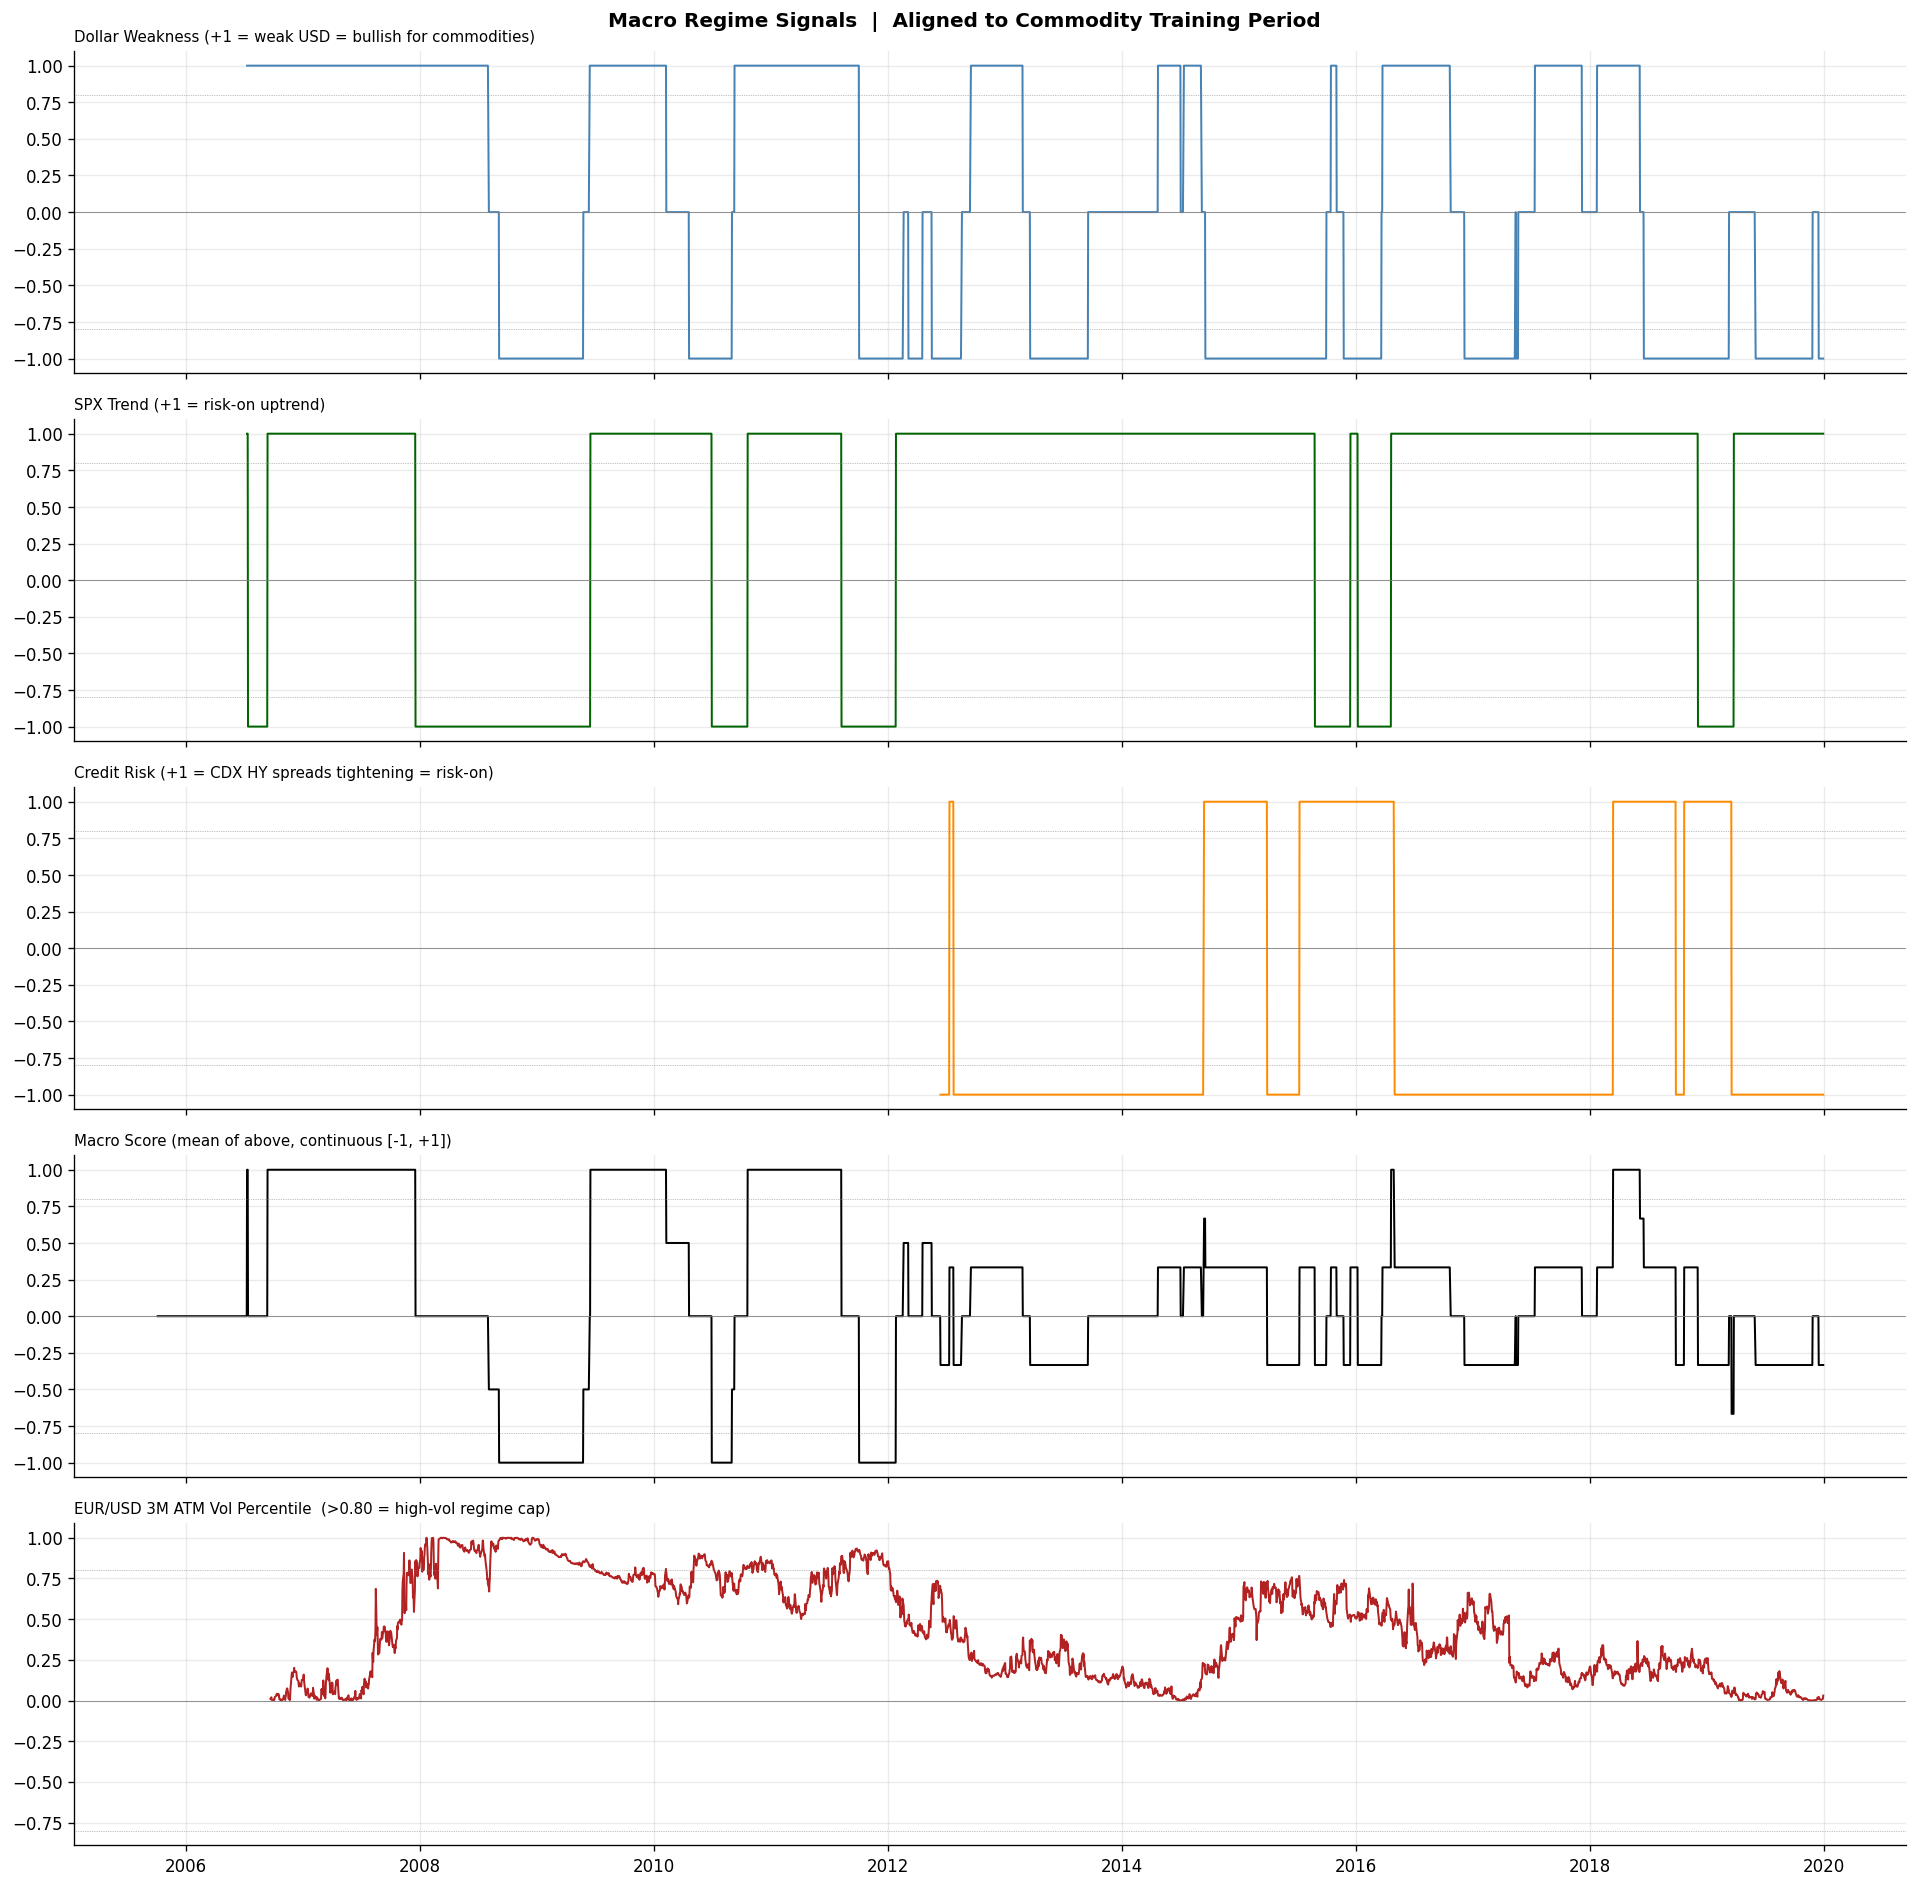

In [237]:
from signals.macro_signal import (dollar_signal, equity_signal, credit_signal,
                                   vol_percentile, macro_regime_score)

d_sig = dollar_signal(fx_spot,  fast=50, slow=200)
e_sig = equity_signal(equity,   fast=50, slow=200)
c_sig = credit_signal(credit,   fast=50, slow=200)
v_pct = vol_percentile(fx_vol)
m_score = macro_regime_score(dollar=d_sig, equity=e_sig, credit=c_sig)

# Align to prices index
d_sig   = d_sig.reindex(prices.index)
e_sig   = e_sig.reindex(prices.index)
c_sig   = c_sig.reindex(prices.index)
v_pct   = v_pct.reindex(prices.index)
m_score = m_score.reindex(prices.index).fillna(0)

fig, axes = plt.subplots(5, 1, figsize=(16, 16), sharex=True)
fig.suptitle('Macro Regime Signals  |  Aligned to Commodity Training Period',
             fontweight='bold', fontsize=12)

panel_data = [
    (d_sig,   'Dollar Weakness (+1 = weak USD = bullish for commodities)',    'steelblue'),
    (e_sig,   'SPX Trend (+1 = risk-on uptrend)',                             'darkgreen'),
    (c_sig,   'Credit Risk (+1 = CDX HY spreads tightening = risk-on)',       'darkorange'),
    (m_score, 'Macro Score (mean of above, continuous [-1, +1])',             'black'),
    (v_pct,   'EUR/USD 3M ATM Vol Percentile  (>0.80 = high-vol regime cap)', 'firebrick'),
]
for ax, (s, title, col) in zip(axes, panel_data):
    ax.plot(s.index, s.values, color=col, lw=1.2)
    if s.abs().max() <= 1.05:   # signal series
        ax.axhline(0,  color='grey', lw=0.5)
        ax.axhline( 0.80, color='grey', lw=0.4, linestyle=':')
        ax.axhline(-0.80, color='grey', lw=0.4, linestyle=':')
    ax.set_title(title, fontsize=9, loc='left')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()


### 0.2 Baseline Comparison Setup
Run the Task 1 baseline once so the enhanced charts and tables can compare against the original strategy.


In [238]:
# Run baseline strategy (Task 1) — needed for comparison charts
from strategy import run_strategy as _run_base

positions, weights, port_r = _run_base(
    prices,
    returns        = returns,
    filter_fast    = 50,
    filter_slow    = 200,
    slope_lookback = 100,
    ema_window     = 14,
    rsi_window     = 14,
    rsi_long_level = 50.0,
    rsi_level      = 60.0,
    rsi_flag_window= 5,
    bb_window      = 100,
    bb_num_std     = 2.0,
    atr_window     = 50,
    sl_mult        = 3.0,
    risk_per_trade = 0.01,
    max_weight     = 0.20,
    leverage_cap   = 2.50,
)


## 1. Control Panel
Central parameter block for the enhanced strategy. Keep the RSI short cap, SAR settings, macro sizing, and cost assumptions visible here before running the pipeline.


In [239]:
# ── Layer 1 — Regime filter (Enhanced) ────────────────────────────────────────
ENH_FILTER_FAST = 50
ENH_FILTER_SLOW = 200
# Lookbacks default: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110]

# ── Layer 2 — Entry timing (Enhanced) ─────────────────────────────────────────
ENH_EMA_WINDOW      = 14
ENH_RSI_WINDOW      = 14
ENH_RSI_LONG_LEVEL  = 50.0
ENH_RSI_LEVEL       = 60.0
ENH_RSI_FLAG_WINDOW = 5
ENH_RSI_SHORT_CAP   = 50.0   # short blocked if RSI < this at execution bar

# ── Slot manager — Parabolic SAR ───────────────────────────────────────────────
ENH_BB_WINDOW        = 100
ENH_BB_NUM_STD       = 2.0
ENH_ATR_WINDOW       = 50
ENH_SAR_INITIAL_MULT = 2.5
ENH_SAR_AF_START     = 0.01
ENH_SAR_AF_STEP      = 0.03
ENH_SAR_AF_MAX       = 0.20
ENH_SAR_GRACE_PERIOD = 5

# ── Portfolio — conviction-weighted sizing ─────────────────────────────────────
ENH_SL_MULT        = 3.0    # portfolio sizing stop-distance assumption
ENH_RISK_PER_TRADE = 0.01   # max capital risked per trade (scaled by conviction)
ENH_MAX_WEIGHT     = 0.20
ENH_LEVERAGE_CAP   = 2.50
ENH_TX_COST_BPS    = 2.0    # one-way transaction cost in bps

# ── Macro regime modulation ────────────────────────────────────────────────────
ENH_MACRO_ALPHA   = 0.5    # macro blend weight (0 = no effect, 1 = full blend)
ENH_MACRO_FAST    = 50     # SMA fast period for macro signals
ENH_MACRO_SLOW    = 200    # SMA slow period for macro signals
ENH_VOL_CAP_PCT   = 0.80   # FX vol percentile above which conviction is capped
ENH_VOL_DAMPEN    = 0.5    # conviction multiplier during high-vol regime


## 2. Strategy Run
Run the full Task 2 enhanced pipeline once with the control-panel parameters. Downstream diagnostics use these `pos_enh`, `wgt_enh`, and `port_r_enh` objects.


In [240]:
from strategy_enhanced import build_signals as build_signals_enh, run_strategy as run_strategy_enh
from diagnostics import transaction_cost_sensitivity, sl_mult_grid_search, sar_grid_search

enhanced_kwargs = dict(
    # Layer 1
    filter_fast = ENH_FILTER_FAST,
    filter_slow = ENH_FILTER_SLOW,
    # Layer 2
    ema_window      = ENH_EMA_WINDOW,
    rsi_window      = ENH_RSI_WINDOW,
    rsi_long_level  = ENH_RSI_LONG_LEVEL,
    rsi_level       = ENH_RSI_LEVEL,
    rsi_flag_window = ENH_RSI_FLAG_WINDOW,
    rsi_short_cap   = ENH_RSI_SHORT_CAP,
    # Slot manager — SAR
    bb_window        = ENH_BB_WINDOW,
    bb_num_std       = ENH_BB_NUM_STD,
    atr_window       = ENH_ATR_WINDOW,
    sar_initial_mult = ENH_SAR_INITIAL_MULT,
    sar_af_start     = ENH_SAR_AF_START,
    sar_af_step      = ENH_SAR_AF_STEP,
    sar_af_max       = ENH_SAR_AF_MAX,
    sar_grace_period = ENH_SAR_GRACE_PERIOD,
    # Portfolio — conviction-weighted sizing
    sl_mult        = ENH_SL_MULT,
    risk_per_trade = ENH_RISK_PER_TRADE,
    max_weight     = ENH_MAX_WEIGHT,
    leverage_cap   = ENH_LEVERAGE_CAP,
    # Macro regime data
    external      = external,
    macro_alpha   = ENH_MACRO_ALPHA,
    macro_fast    = ENH_MACRO_FAST,
    macro_slow    = ENH_MACRO_SLOW,
    vol_cap_pct   = ENH_VOL_CAP_PCT,
    vol_dampen    = ENH_VOL_DAMPEN,
)

pos_enh, wgt_enh, port_r_enh = run_strategy_enh(
    prices,
    returns = returns,
    tx_cost_bps = ENH_TX_COST_BPS,
    **enhanced_kwargs,
)

pos_enh_gross, wgt_enh_gross, port_r_enh_gross = run_strategy_enh(
    prices,
    returns = returns,
    tx_cost_bps = 0.0,
    **enhanced_kwargs,
)

print(f'Enhanced net returns use tx_cost_bps = {ENH_TX_COST_BPS:g}')
print('Gross no-cost returns are available as port_r_enh_gross')


Enhanced net returns use tx_cost_bps = 2
Gross no-cost returns are available as port_r_enh_gross


## 3. Signal Diagnostics
The next cells inspect the enhanced signal stack before evaluating performance.

### 3.1 Layer 1 Regime Filter
Measure the binary enhanced regime filter by commodity.


In [241]:
from signals.signal_layer1_enhanced import layer1_signal as l1_enh_fn, regime_strength

l1_strength = regime_strength(prices, fast=ENH_FILTER_FAST, slow=ENH_FILTER_SLOW)
l1_enh      = l1_enh_fn(prices, filter_fast=ENH_FILTER_FAST, filter_slow=ENH_FILTER_SLOW)

print(f'prices      : {prices.shape}')
print(f'l1_strength : {l1_strength.shape}  — continuous [-1, +1]  (10 lookbacks: 20–110d)')
print(f'l1_enh      : {l1_enh.shape}   — binary {{-1, 0, +1, NaN}}')
print()

total = len(l1_enh)
counts_df = pd.DataFrame({
    'Long (+1)'       : (l1_enh ==  1).sum(),
    'Neutral (0)'     : (l1_enh ==  0).sum(),
    'Short (-1)'      : (l1_enh == -1).sum(),
    'NaN (warmup)'    : l1_enh.isna().sum(),
    '% Long'          : ((l1_enh ==  1).sum() / total * 100).round(1),
    '% Neutral'       : ((l1_enh ==  0).sum() / total * 100).round(1),
    '% Short'         : ((l1_enh == -1).sum() / total * 100).round(1),
    'Mean |strength|' : l1_strength.abs().mean().round(3),
})
counts_df.index.name = 'Commodity'
display(counts_df)


prices      : (3715, 23)
l1_strength : (3715, 23)  — continuous [-1, +1]  (10 lookbacks: 20–110d)
l1_enh      : (3715, 23)   — binary {-1, 0, +1, NaN}



,Long (+1),Neutral (0),Short (-1),NaN (warmup),% Long,% Neutral,% Short,Mean |strength|
Commodity,,,,,,,,
LIVE CATTLE,1064,773,1569,309,28.6,20.8,42.2,0.735
LEAN HOGS,511,1009,1886,309,13.8,27.2,50.8,0.659
COFFEE 'C',795,720,1891,309,21.4,19.4,50.9,0.765
CORN,735,690,1981,309,19.8,18.6,53.3,0.760
COTTON NO.2,1329,707,1370,309,35.8,19.0,36.9,0.748
SOYBEAN,1387,709,1310,309,37.3,19.1,35.3,0.733
SUGAR #11,685,771,1950,309,18.4,20.8,52.5,0.745
WHEAT FUTURE,655,598,2153,309,17.6,16.1,58.0,0.788
BRENT CRUDE,1715,724,967,309,46.2,19.5,26.0,0.743


### 3.2 Layer 1 Regime Strength Chart
Visualise the continuous conviction grid used for position sizing.


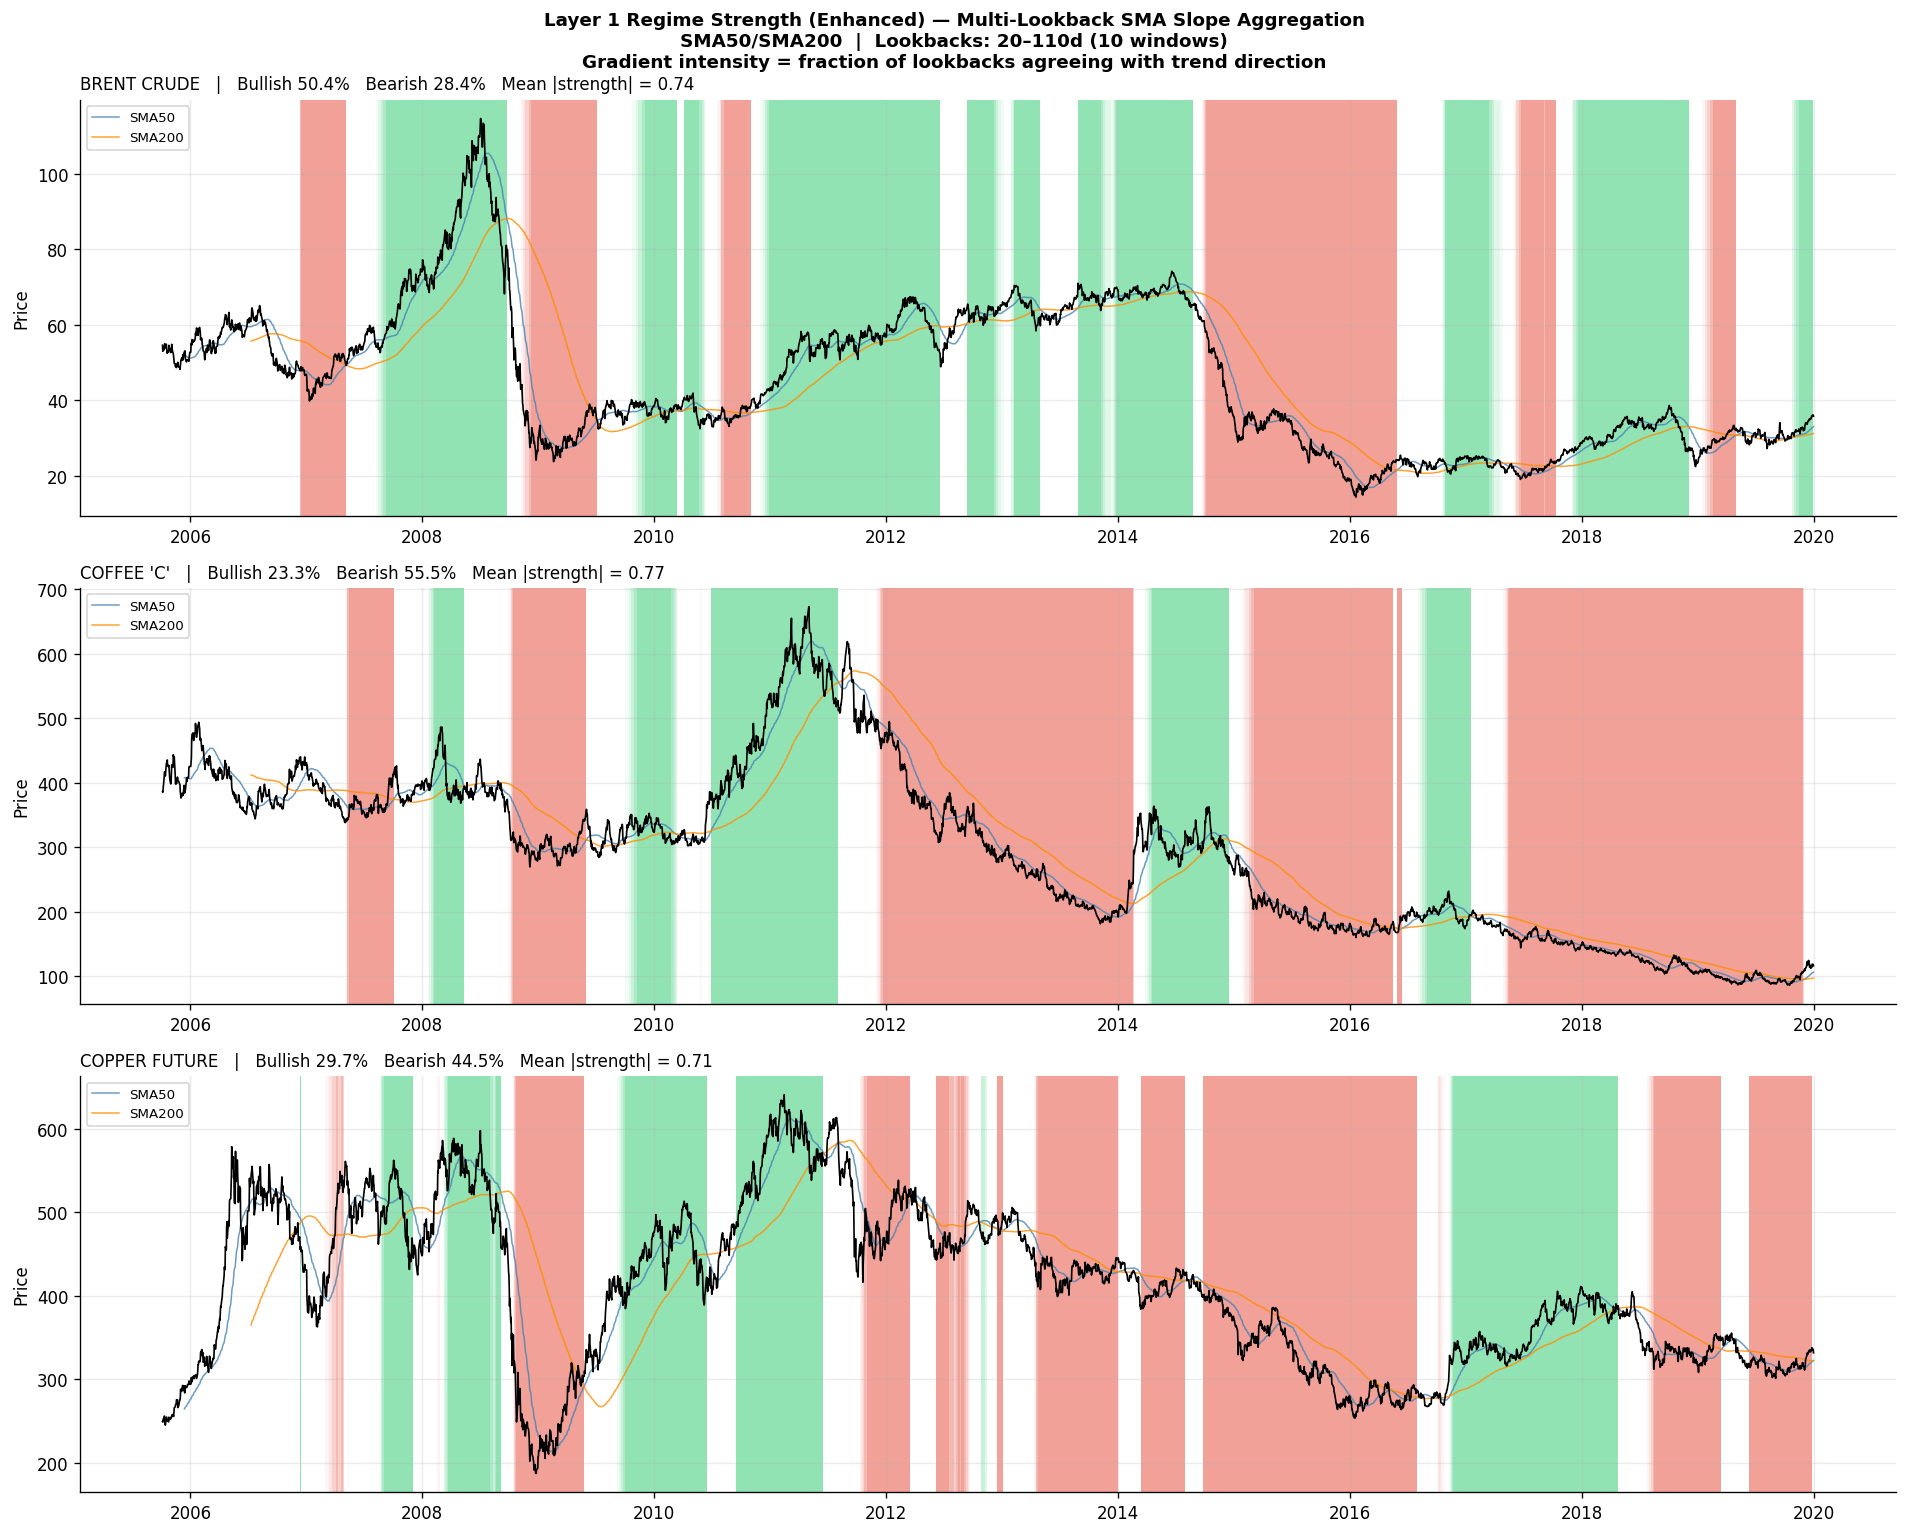

In [242]:
LEVELS = [(0.2, 0.06), (0.4, 0.09), (0.6, 0.13), (0.8, 0.17), (1.0, 0.22)]
REGIME_COMDTIES = ['BRENT CRUDE', "COFFEE 'C'", 'COPPER FUTURE']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
fig.suptitle(
    f'Layer 1 Regime Strength (Enhanced) — Multi-Lookback SMA Slope Aggregation\n'
    f'SMA{ENH_FILTER_FAST}/SMA{ENH_FILTER_SLOW}  |  Lookbacks: 20–110d (10 windows)\n'
    f'Gradient intensity = fraction of lookbacks agreeing with trend direction',
    fontweight='bold', fontsize=11
)

for ax, col in zip(axes, REGIME_COMDTIES):
    p     = prices[col]
    stren = l1_strength[col]
    sig   = l1_enh[col]

    sma_fast = p.rolling(ENH_FILTER_FAST).mean()
    sma_slow = p.rolling(ENH_FILTER_SLOW).mean()

    ax.plot(p.index, p.values,        color='black',      lw=1.0, zorder=3)
    ax.plot(p.index, sma_fast.values, color='steelblue',  lw=0.9, alpha=0.8, label=f'SMA{ENH_FILTER_FAST}')
    ax.plot(p.index, sma_slow.values, color='darkorange', lw=0.9, alpha=0.8, label=f'SMA{ENH_FILTER_SLOW}')

    for thresh, alpha in LEVELS:
        ax.fill_between(p.index, 0, 1,
                        where=(stren >= thresh),
                        transform=ax.get_xaxis_transform(),
                        color='#2ecc71', alpha=alpha, lw=0, zorder=1)
        ax.fill_between(p.index, 0, 1,
                        where=(stren <= -thresh),
                        transform=ax.get_xaxis_transform(),
                        color='#e74c3c', alpha=alpha, lw=0, zorder=1)

    n_total  = sig.notna().sum()
    pct_bull = (sig ==  1).sum() / n_total * 100
    pct_bear = (sig == -1).sum() / n_total * 100
    mean_abs = stren.abs().mean()

    ax.set_title(
        f'{col}   |   Bullish {pct_bull:.1f}%   Bearish {pct_bear:.1f}%   '
        f'Mean |strength| = {mean_abs:.2f}',
        fontsize=10, loc='left'
    )
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Price')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()


### 3.3 Layer 2 Entry Signals
Count enhanced entry events, including the stricter short RSI trigger. The short RSI cap is checked later at execution time.


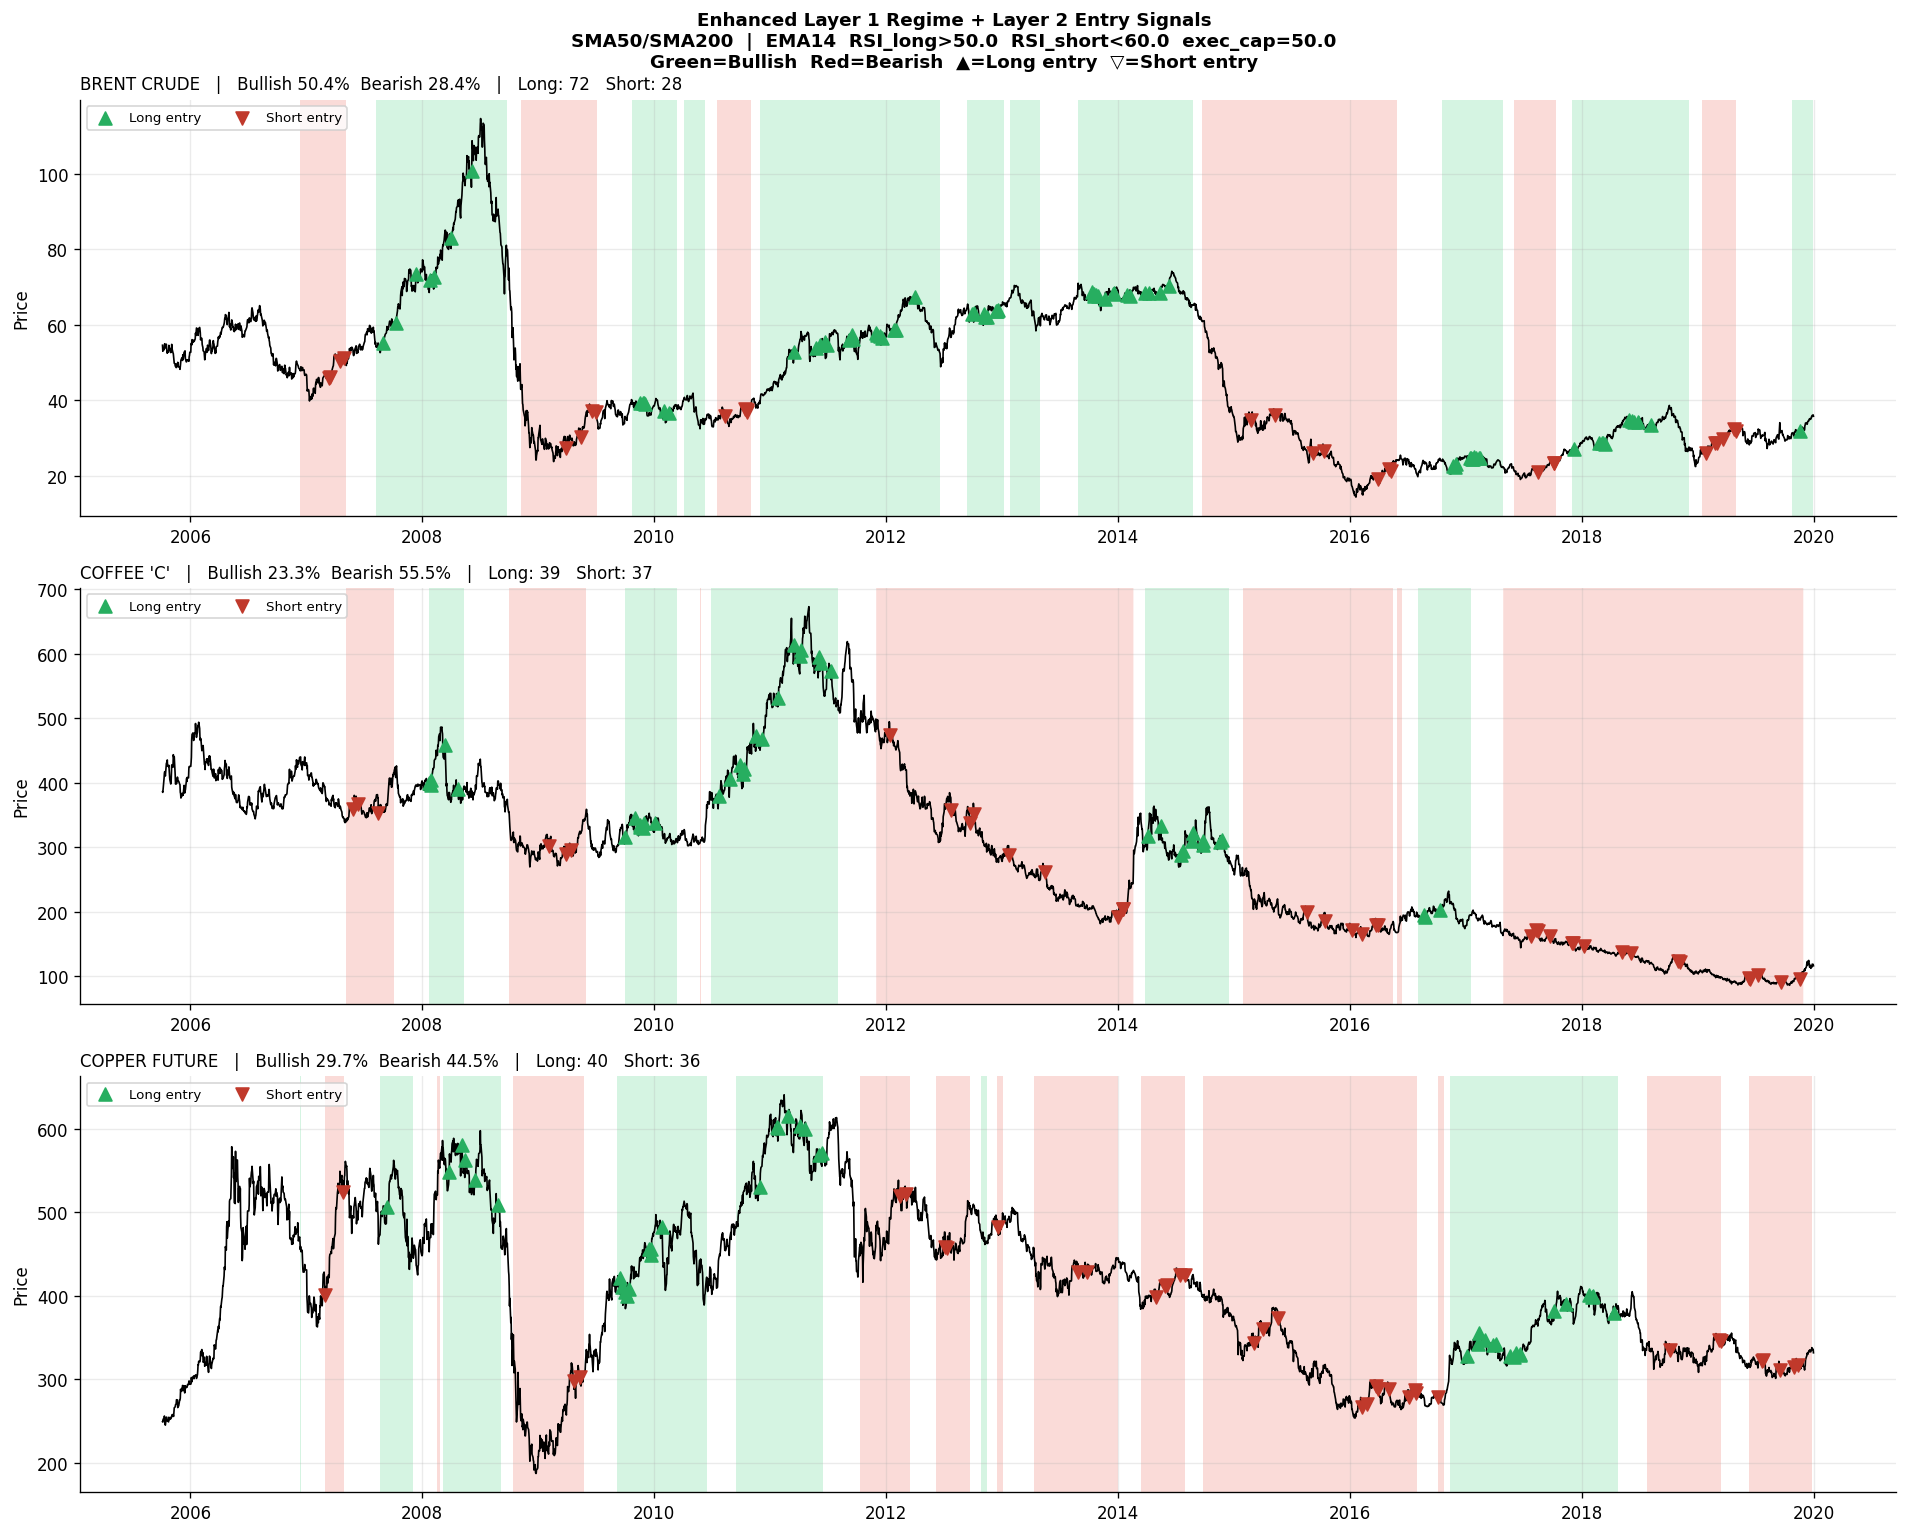

In [243]:
from signals.signal_layer2_enhanced import layer2_signal as l2_enh_fn

l2_enh = l2_enh_fn(prices, layer1=l1_enh,
                   ema_window=ENH_EMA_WINDOW, rsi_window=ENH_RSI_WINDOW,
                   rsi_long_level=ENH_RSI_LONG_LEVEL, rsi_level=ENH_RSI_LEVEL,
                   rsi_flag_window=ENH_RSI_FLAG_WINDOW)

REGIME_COMDTIES = ['BRENT CRUDE', "COFFEE 'C'", 'COPPER FUTURE']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
fig.suptitle(
    f'Enhanced Layer 1 Regime + Layer 2 Entry Signals\n'
    f'SMA{ENH_FILTER_FAST}/SMA{ENH_FILTER_SLOW}  |  '
    f'EMA{ENH_EMA_WINDOW}  RSI_long>{ENH_RSI_LONG_LEVEL}  RSI_short<{ENH_RSI_LEVEL}  exec_cap={ENH_RSI_SHORT_CAP}\n'
    f'Green=Bullish  Red=Bearish  ▲=Long entry  ▽=Short entry',
    fontweight='bold', fontsize=11
)

for ax, col in zip(axes, REGIME_COMDTIES):
    p    = prices[col]
    sig1 = l1_enh[col]
    sig2 = l2_enh[col]

    ax.plot(p.index, p.values, color='black', lw=1.0, zorder=3)
    ax.fill_between(p.index, 0, 1, where=(sig1 == 1),
                    transform=ax.get_xaxis_transform(),
                    color='#2ecc71', alpha=0.20, lw=0, zorder=1)
    ax.fill_between(p.index, 0, 1, where=(sig1 == -1),
                    transform=ax.get_xaxis_transform(),
                    color='#e74c3c', alpha=0.20, lw=0, zorder=1)

    long_days  = sig2[sig2 ==  1].index
    short_days = sig2[sig2 == -1].index
    ax.scatter(long_days,  p.loc[long_days],  marker='^', color='#27ae60', s=60, zorder=5, label='Long entry')
    ax.scatter(short_days, p.loc[short_days], marker='v', color='#c0392b', s=60, zorder=5, label='Short entry')

    n_total  = sig1.notna().sum()
    pct_bull = (sig1 ==  1).sum() / n_total * 100
    pct_bear = (sig1 == -1).sum() / n_total * 100
    ax.set_title(
        f'{col}   |   Bullish {pct_bull:.1f}%  Bearish {pct_bear:.1f}%   |   '
        f'Long: {len(long_days)}   Short: {len(short_days)}',
        fontsize=10, loc='left'
    )
    ax.set_ylabel('Price')
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()


## 4. Position And Risk Diagnostics
The next cells inspect realised positions, SAR-managed exits, and macro effects after the enhanced pipeline runs.

### 4.1 Position Grid Analysis
Summarise long, short, and flat exposure after applying execution-time RSI cap, SAR exits, and no-clustering.


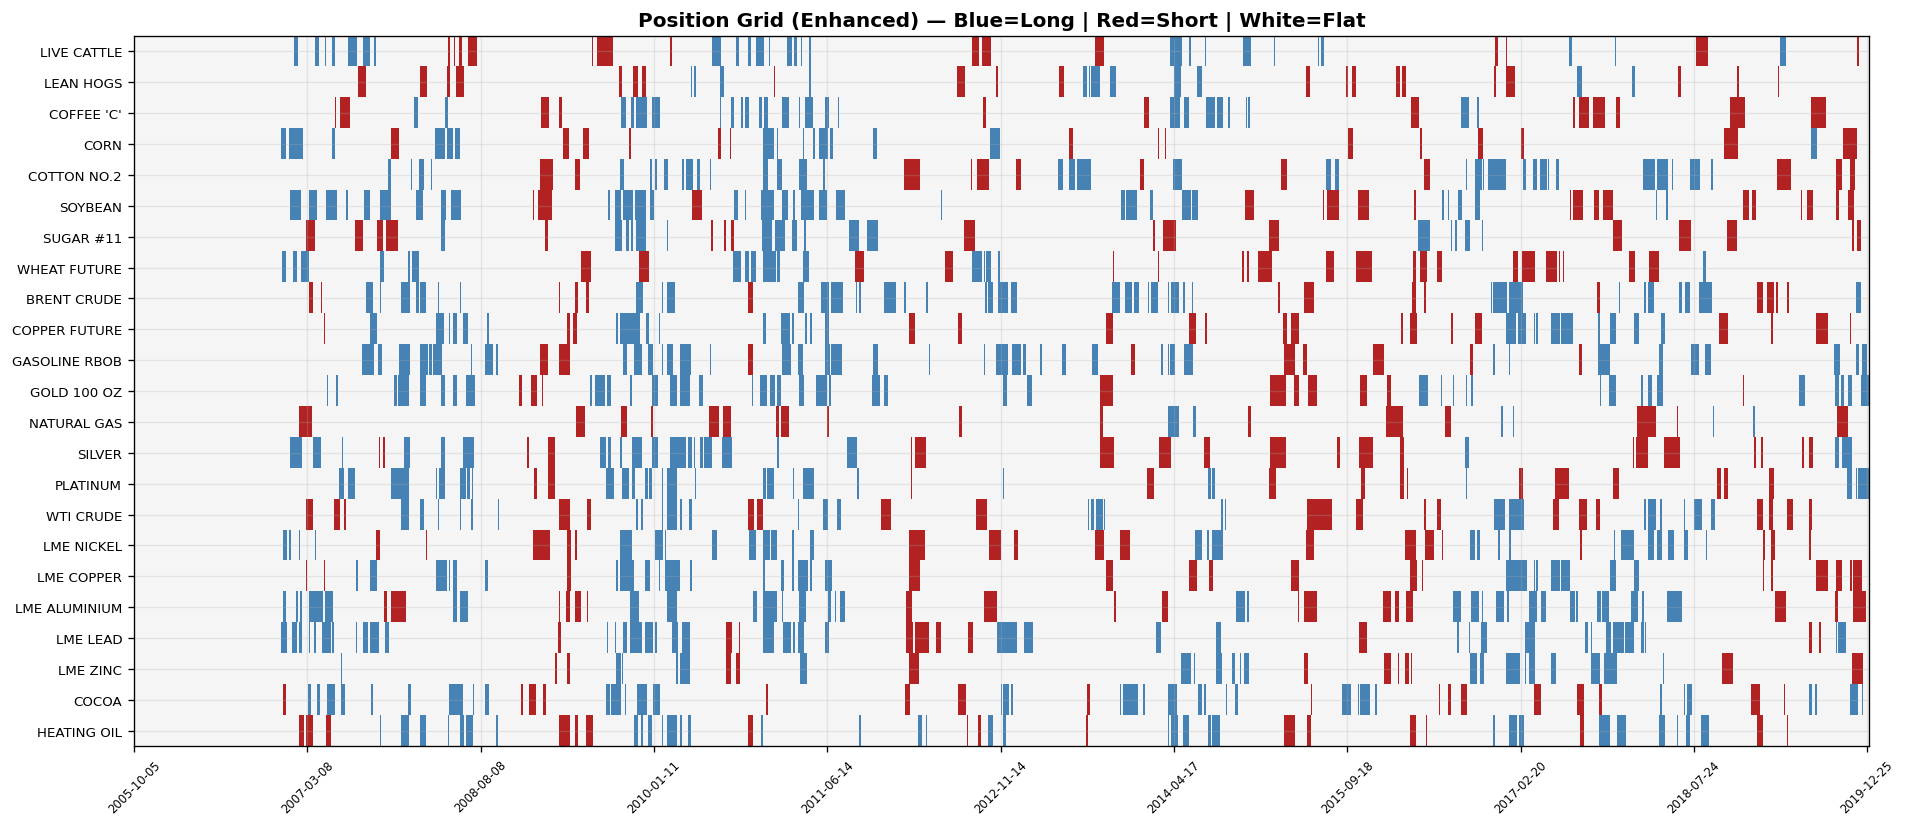

               Days Long  Days Short  Days Flat  % Long  % Short
LIVE CATTLE          225         169       3321     6.1      4.5
LEAN HOGS            102         190       3423     2.7      5.1
COFFEE 'C'           250         206       3259     6.7      5.5
CORN                 190         163       3362     5.1      4.4
COTTON NO.2          382         200       3133    10.3      5.4
SOYBEAN              456         238       3021    12.3      6.4
SUGAR #11            208         250       3257     5.6      6.7
WHEAT FUTURE         188         311       3216     5.1      8.4
BRENT CRUDE          458         116       3141    12.3      3.1
COPPER FUTURE        285         188       3242     7.7      5.1
GASOLINE RBOB        501         126       3088    13.5      3.4
GOLD 100 OZ          430         142       3143    11.6      3.8
NATURAL GAS           44         259       3412     1.2      7.0
SILVER               303         284       3128     8.2      7.6
PLATINUM             285 

In [244]:
import matplotlib.colors as mcolors

cmap  = mcolors.ListedColormap(['firebrick', 'whitesmoke', 'steelblue'])
norm  = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
step  = max(1, len(pos_enh) // 10)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(pos_enh.T.values, aspect='auto', cmap=cmap, norm=norm, interpolation='none')
ax.set_yticks(range(len(pos_enh.columns)))
ax.set_yticklabels(pos_enh.columns, fontsize=8)
ax.set_xticks(range(0, len(pos_enh), step))
ax.set_xticklabels([str(d.date()) for d in pos_enh.index[::step]], rotation=45, fontsize=7)
ax.set_title('Position Grid (Enhanced) — Blue=Long | Red=Short | White=Flat', fontweight='bold')
fig.tight_layout()
plt.show()

print(position_summary(pos_enh))


### 4.2 Sample Trades: Entry To Exit
These charts reconstruct seven selected enhanced Task 2 trades using the same close-price SAR-style logic as the slot manager. The `sl_mult` line is shown only as the portfolio sizing stop-distance reference; it is not the actual Task 2 exit stop.


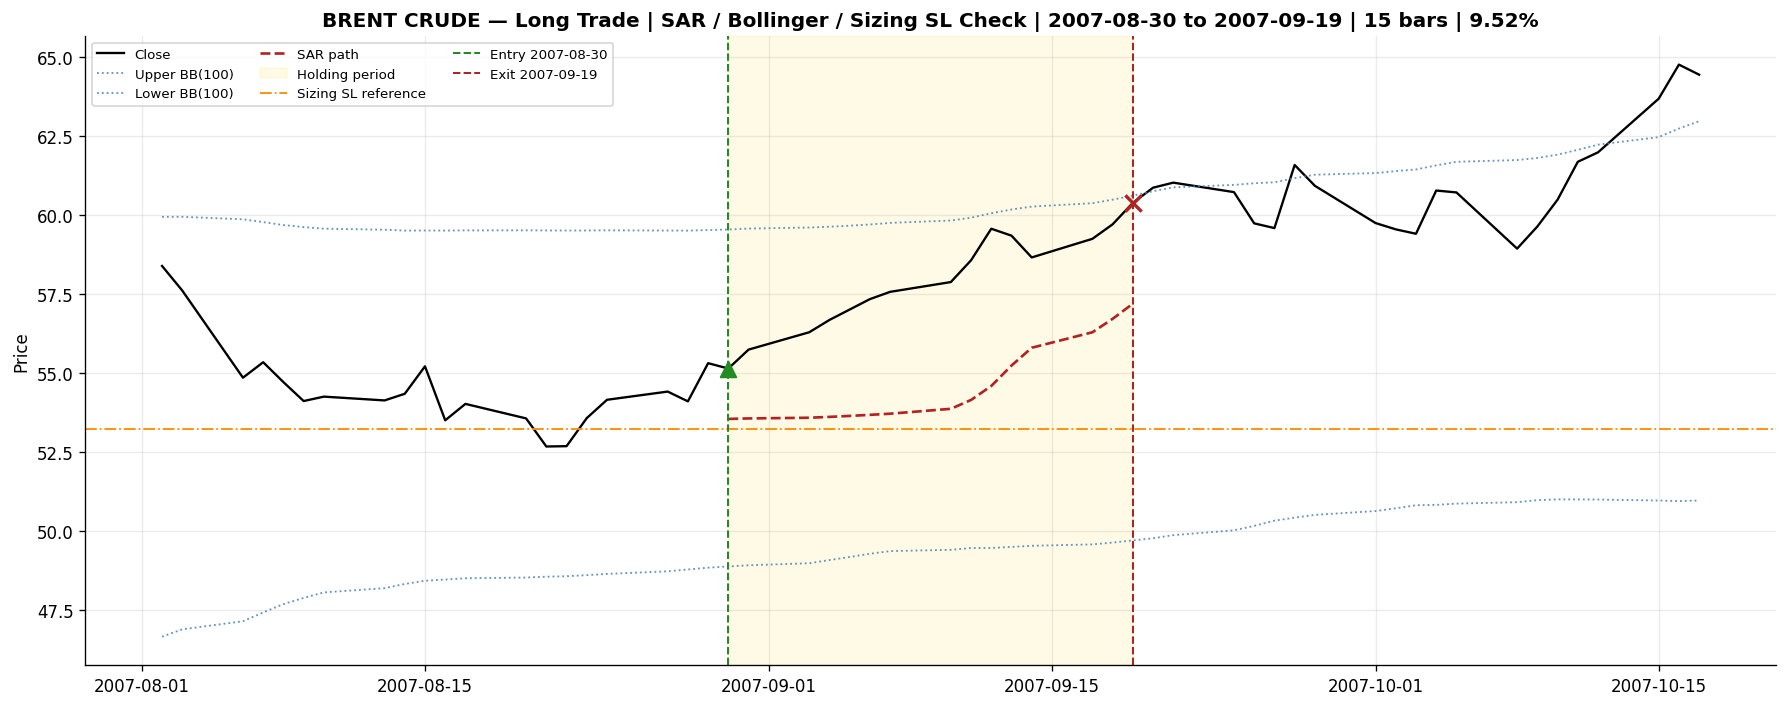

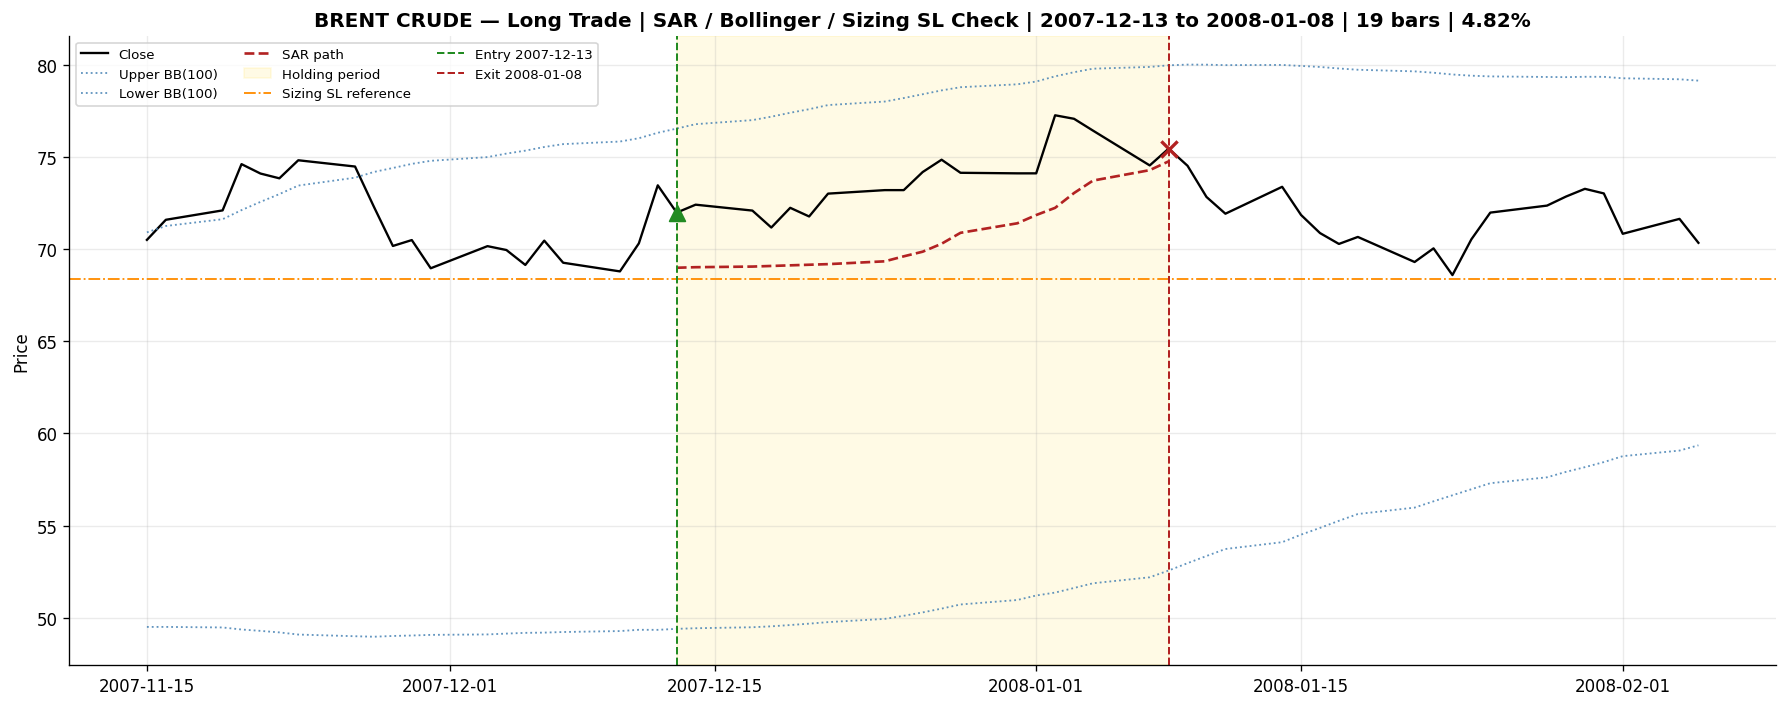

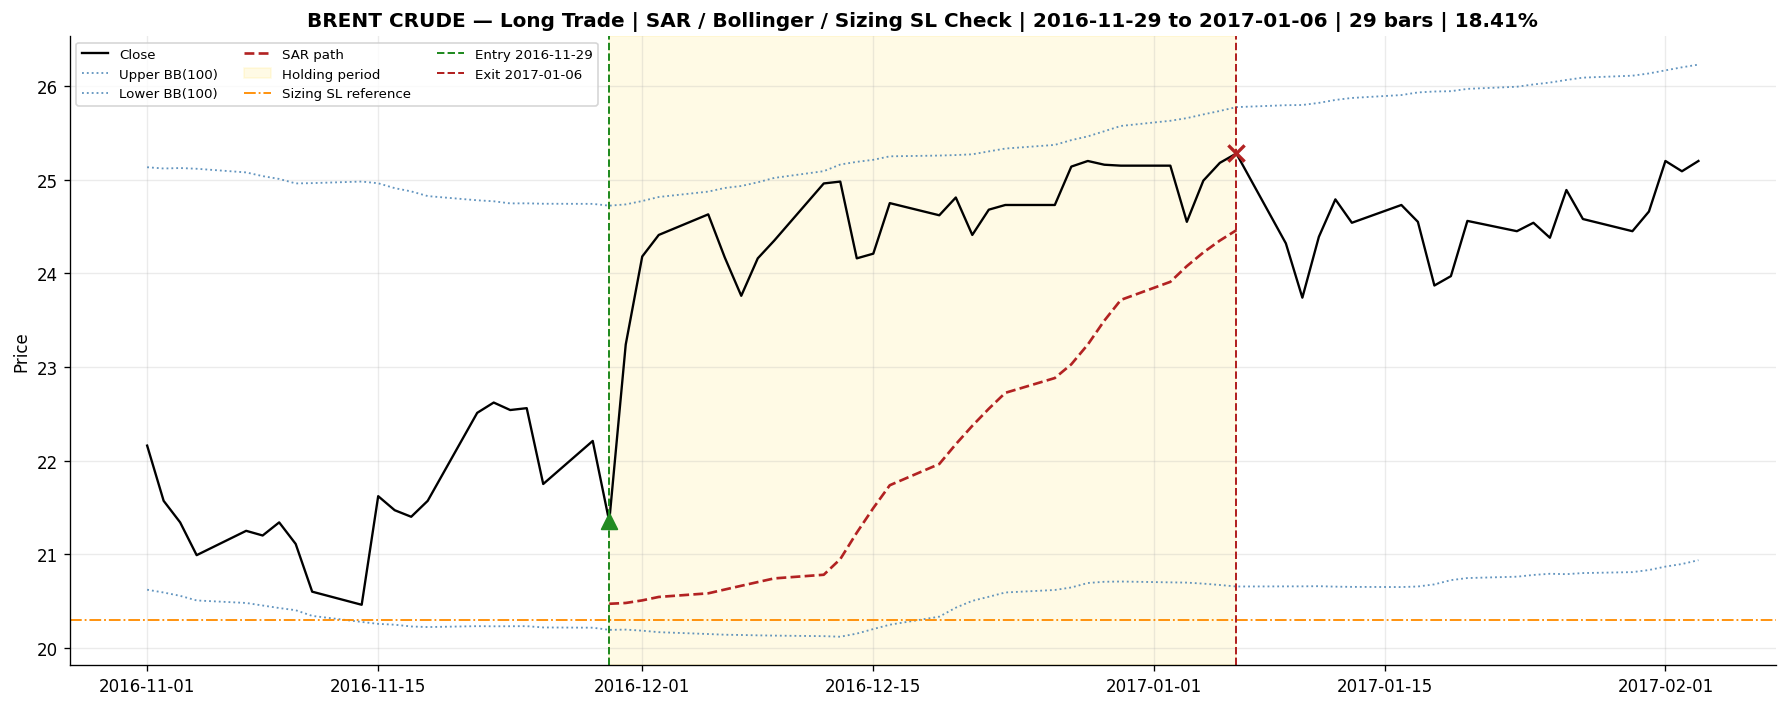

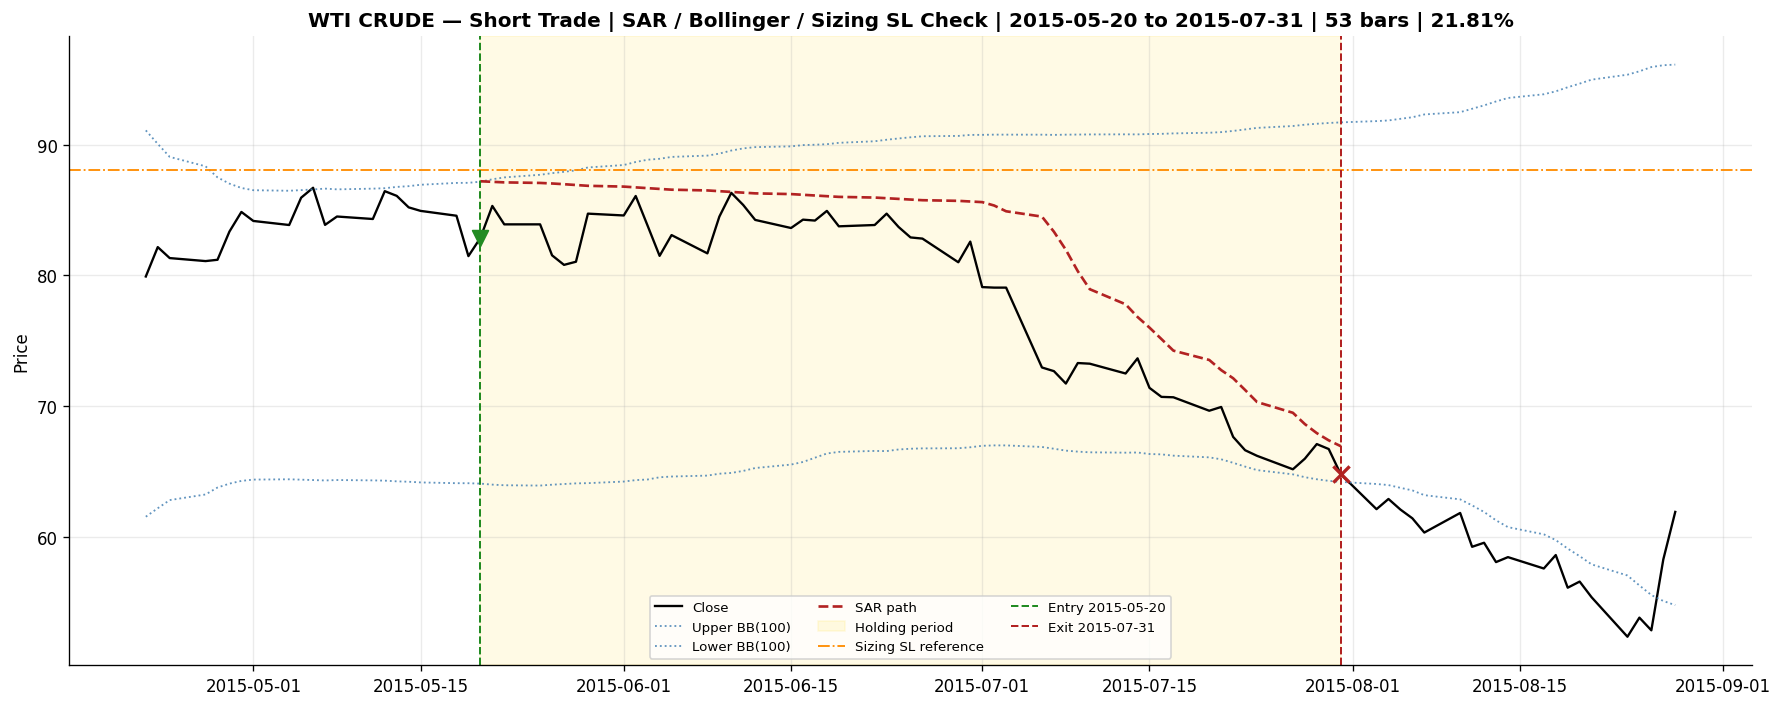

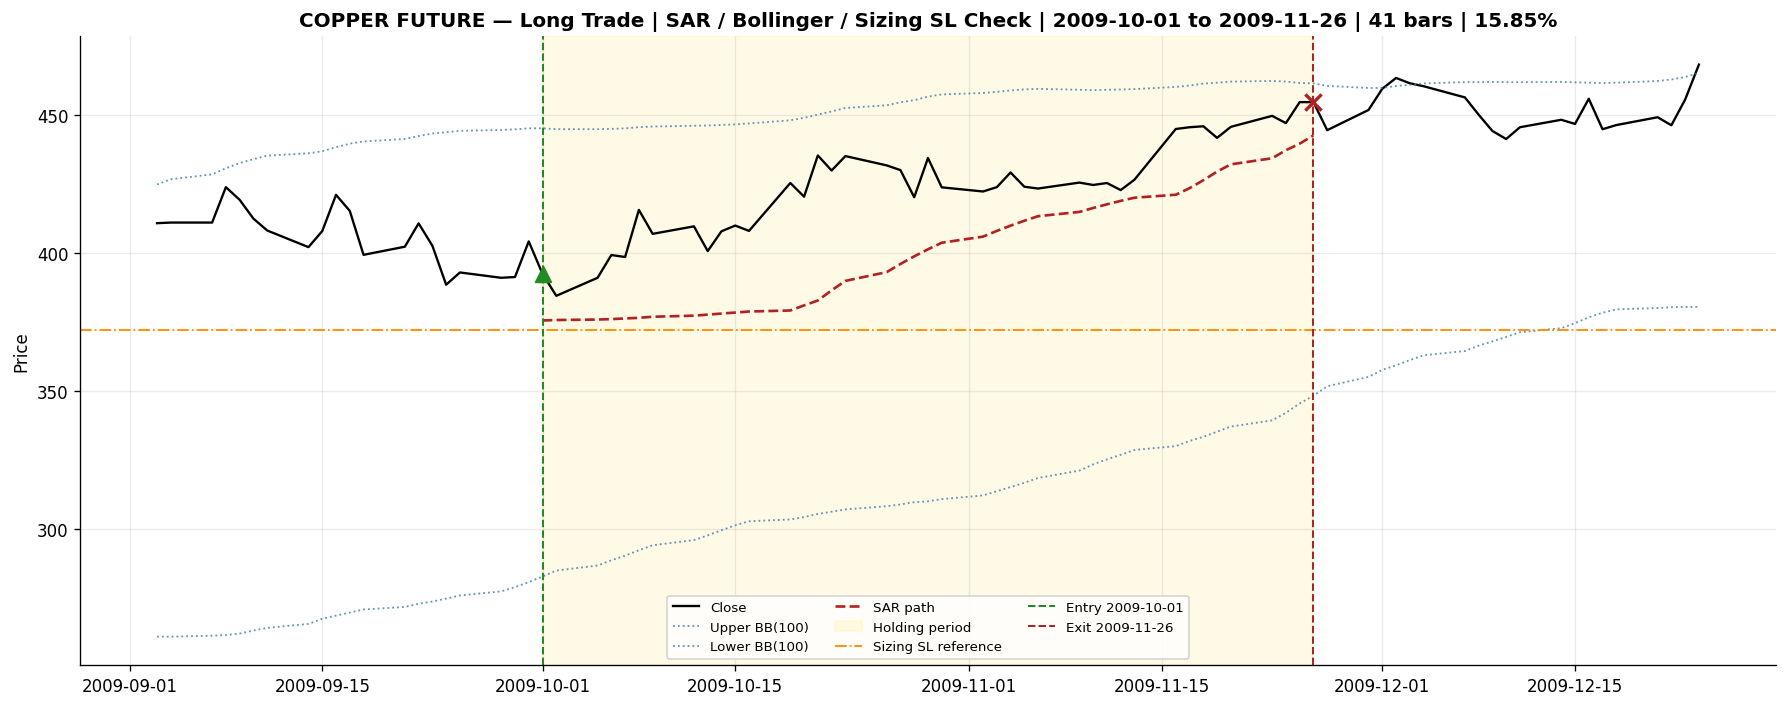

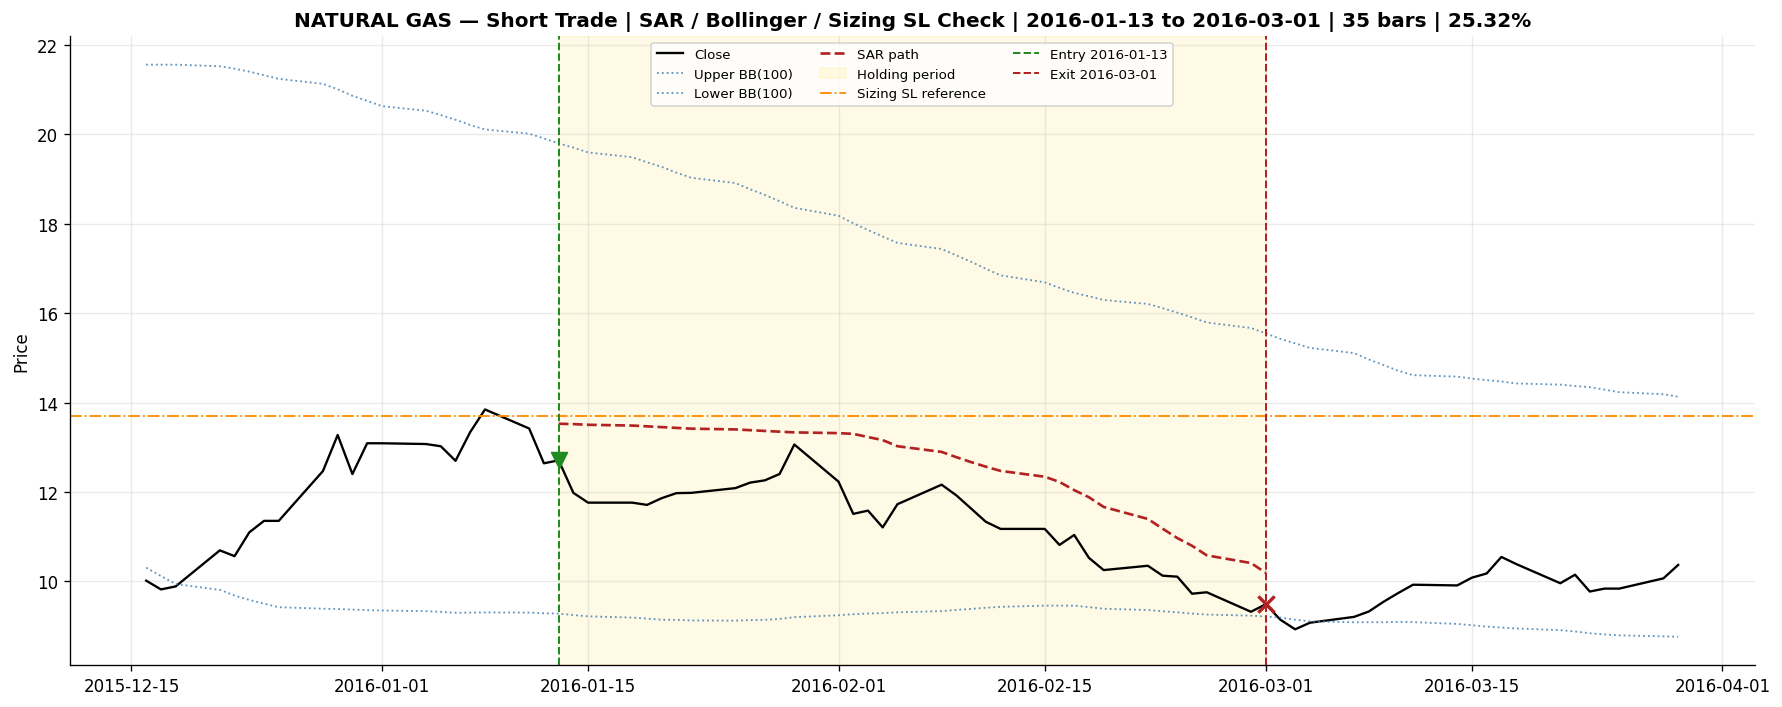

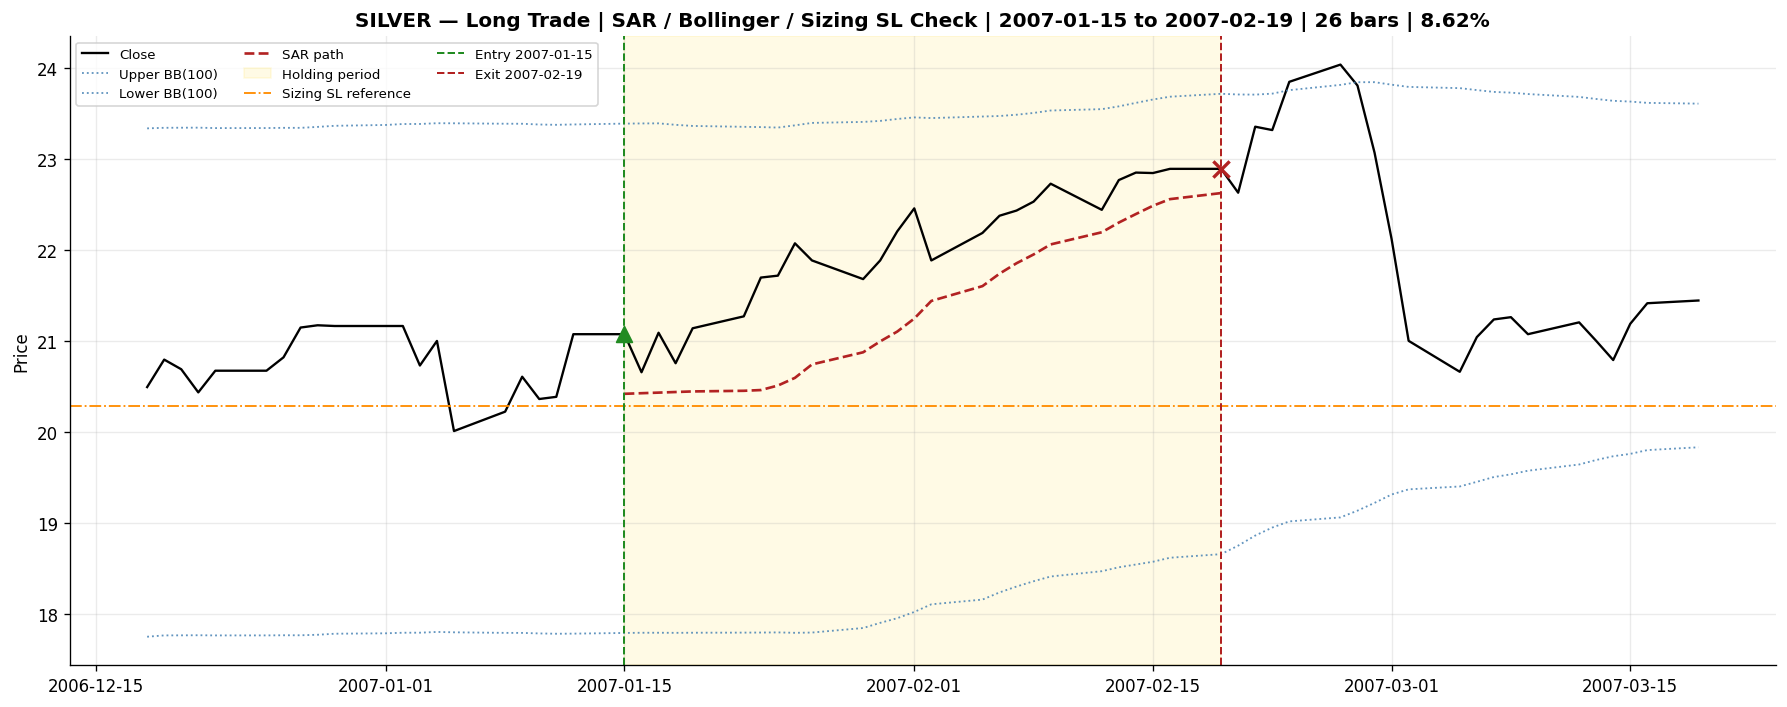

,commodity,side,entry_date,exit_date,holding_bars,trade_return,entry_price,exit_price,entry_atr_pct,initial_sar,sizing_sl_reference
0,BRENT CRUDE,Long,2007-08-30,2007-09-19,15,0.0952,55.140,60.390,0.011582,53.5434,53.2240
1,BRENT CRUDE,Long,2007-12-13,2008-01-08,19,0.0482,71.980,75.450,0.016628,68.9878,68.3893
2,BRENT CRUDE,Long,2016-11-29,2017-01-06,29,0.1841,21.350,25.280,0.016477,20.4705,20.2946
3,WTI CRUDE,Short,2015-05-20,2015-07-31,53,0.2181,82.870,64.800,0.020939,87.2080,88.0756
4,COPPER FUTURE,Long,2009-10-01,2009-11-26,41,0.1585,392.580,454.800,0.017215,375.6842,372.3050
5,NATURAL GAS,Short,2016-01-13,2016-03-01,35,0.2532,12.709,9.491,0.025743,13.5269,13.6905
6,SILVER,Long,2007-01-15,2007-02-19,26,0.0862,21.078,22.894,0.012425,20.4233,20.2923


In [245]:
from indicators import atr_pct, bollinger_bands


SAMPLE_TRADES = [
    {'commodity': 'BRENT CRUDE', 'side': 'Long',  'entry': '2007-08-30', 'exit': '2007-09-19'},
    {'commodity': 'BRENT CRUDE', 'side': 'Long',  'entry': '2007-12-13', 'exit': '2008-01-08'},
    {'commodity': 'BRENT CRUDE', 'side': 'Long',  'entry': '2016-11-29', 'exit': '2017-01-06'},
    {'commodity': 'WTI CRUDE',   'side': 'Short', 'entry': '2015-05-20', 'exit': '2015-07-31'},
    {'commodity': 'COPPER FUTURE','side': 'Long',  'entry': '2009-10-01', 'exit': '2009-11-26'},
    {'commodity': 'NATURAL GAS',  'side': 'Short', 'entry': '2016-01-13', 'exit': '2016-03-01'},
    {'commodity': 'SILVER',       'side': 'Long',  'entry': '2007-01-15', 'exit': '2007-02-19'},
]


def _completed_trade_runs(position_series: pd.Series) -> list[dict]:
    """Return continuous nonzero position runs that later close to flat."""
    trades = []
    active = None
    pos = position_series.fillna(0).astype(int)

    for i, (date, value) in enumerate(pos.items()):
        if active is None:
            if value != 0:
                active = {'direction': value, 'entry_idx': i, 'entry_date': date}
            continue

        if value == active['direction']:
            continue

        exit_idx = i - 1 if value == 0 else i
        exit_date = pos.index[exit_idx]
        trades.append({
            'direction': active['direction'],
            'entry_idx': active['entry_idx'],
            'entry_date': active['entry_date'],
            'exit_idx': exit_idx,
            'exit_date': exit_date,
        })
        active = None if value == 0 else {'direction': value, 'entry_idx': i, 'entry_date': date}

    return trades


def _find_completed_trade(commodity: str, entry: str, exit_: str) -> dict | None:
    """Find one completed enhanced trade by commodity, entry date, and exit date."""
    if commodity not in pos_enh.columns:
        return None

    entry_ts = pd.Timestamp(entry)
    exit_ts = pd.Timestamp(exit_)
    for trade in _completed_trade_runs(pos_enh[commodity]):
        if trade['entry_date'] == entry_ts and trade['exit_date'] == exit_ts:
            trade['commodity'] = commodity
            return trade
    return None


def _reconstruct_sar(price: pd.Series, atr: pd.Series, trade: dict) -> pd.Series:
    """Rebuild the close-price SAR path for a selected completed trade."""
    direction = trade['direction']
    entry_idx = trade['entry_idx']
    exit_idx = trade['exit_idx']

    sar = pd.Series(np.nan, index=price.index, name='SAR')
    af = ENH_SAR_AF_START
    ep = price.iloc[entry_idx]
    sar.iloc[entry_idx] = price.iloc[entry_idx] * (1.0 - direction * ENH_SAR_INITIAL_MULT * atr.iloc[entry_idx])
    age = 0

    for i in range(entry_idx + 1, exit_idx + 1):
        prev_sar = sar.iloc[i - 1]
        if np.isnan(prev_sar):
            break

        age += 1
        sar_i = prev_sar + af * (ep - prev_sar)
        price_i = price.iloc[i]

        if direction == 1 and price_i > ep:
            ep = price_i
            if age > ENH_SAR_GRACE_PERIOD:
                af = min(af + ENH_SAR_AF_STEP, ENH_SAR_AF_MAX)
        elif direction == -1 and price_i < ep:
            ep = price_i
            if age > ENH_SAR_GRACE_PERIOD:
                af = min(af + ENH_SAR_AF_STEP, ENH_SAR_AF_MAX)

        sar.iloc[i] = sar_i

    return sar


def _plot_sample_trade(spec: dict) -> dict | None:
    """Plot one selected trade with price, SAR, Bollinger Bands, and sizing SL reference."""
    commodity = spec['commodity']
    trade = _find_completed_trade(commodity, spec['entry'], spec['exit'])
    if trade is None:
        print(f"Trade not found in current enhanced positions: {commodity} {spec['entry']} to {spec['exit']}")
        return None

    direction = trade['direction']
    side = 'Long' if direction == 1 else 'Short'
    entry_idx = trade['entry_idx']
    exit_idx = trade['exit_idx']
    entry_date = trade['entry_date']
    exit_date = trade['exit_date']

    price = prices[commodity]
    atr = atr_pct(prices[[commodity]], ENH_ATR_WINDOW)[commodity]
    _, upper_bb, lower_bb = bollinger_bands(prices[[commodity]], ENH_BB_WINDOW, ENH_BB_NUM_STD)
    upper = upper_bb[commodity]
    lower = lower_bb[commodity]
    sar = _reconstruct_sar(price, atr, trade)

    entry_price = price.iloc[entry_idx]
    exit_price = price.iloc[exit_idx]
    atr_entry = atr.iloc[entry_idx]
    sizing_sl = entry_price * (1.0 - direction * ENH_SL_MULT * atr_entry)

    left = max(0, entry_idx - 20)
    right = min(len(price) - 1, exit_idx + 20)
    plot_index = price.index[left:right + 1]
    hold_bars = exit_idx - entry_idx + 1
    trade_return = direction * (exit_price / entry_price - 1.0)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(plot_index, price.loc[plot_index], color='black', lw=1.4, label='Close')
    ax.plot(plot_index, upper.loc[plot_index], color='steelblue', lw=1.1, ls=':', alpha=0.85, label=f'Upper BB({ENH_BB_WINDOW})')
    ax.plot(plot_index, lower.loc[plot_index], color='steelblue', lw=1.1, ls=':', alpha=0.85, label=f'Lower BB({ENH_BB_WINDOW})')
    ax.plot(plot_index, sar.loc[plot_index], color='firebrick', lw=1.6, ls='--', label='SAR path')

    ax.axvspan(entry_date, exit_date, color='gold', alpha=0.10, label='Holding period')
    ax.axhline(sizing_sl, color='darkorange', lw=1.1, ls='-.', label='Sizing SL reference')
    ax.axvline(entry_date, color='forestgreen', lw=1.2, ls='--', label=f'Entry {entry_date.date()}')
    ax.axvline(exit_date, color='firebrick', lw=1.2, ls='--', label=f'Exit {exit_date.date()}')
    ax.scatter([entry_date], [entry_price], marker='^' if direction == 1 else 'v', color='forestgreen', s=90, zorder=5)
    ax.scatter([exit_date], [exit_price], marker='x', color='firebrick', s=95, linewidths=2, zorder=5)

    ax.set_title(
        f"{commodity} — {side} Trade | SAR / Bollinger / Sizing SL Check | "
        f"{entry_date.date()} to {exit_date.date()} | {hold_bars} bars | {trade_return:.2%}",
        fontweight='bold'
    )
    ax.set_ylabel('Price')
    ax.legend(fontsize=8, ncol=3, loc='best')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    plt.show()

    return {
        'commodity': commodity,
        'side': side,
        'entry_date': entry_date.date(),
        'exit_date': exit_date.date(),
        'holding_bars': hold_bars,
        'trade_return': round(float(trade_return), 4),
        'entry_price': round(float(entry_price), 4),
        'exit_price': round(float(exit_price), 4),
        'entry_atr_pct': round(float(atr_entry), 6),
        'initial_sar': round(float(sar.iloc[entry_idx]), 4),
        'sizing_sl_reference': round(float(sizing_sl), 4),
    }


sample_trade_summaries = []
for sample_trade in SAMPLE_TRADES:
    summary = _plot_sample_trade(sample_trade)
    if summary is not None:
        sample_trade_summaries.append(summary)

pd.DataFrame(sample_trade_summaries)


### 4.3 Macro Impact Analysis
Compare raw and macro-adjusted conviction to confirm macro is acting as a sizing overlay rather than a direction signal.


Regime-active bars:  60,512
  Boosted by macro :  54.8%  (macro agreement → larger size)
  Damped by macro  :  30.2%  (macro opposition → smaller size)
  High-vol cap days:  16.2%  (EURUSD 3M ATM vol > 80% pct)


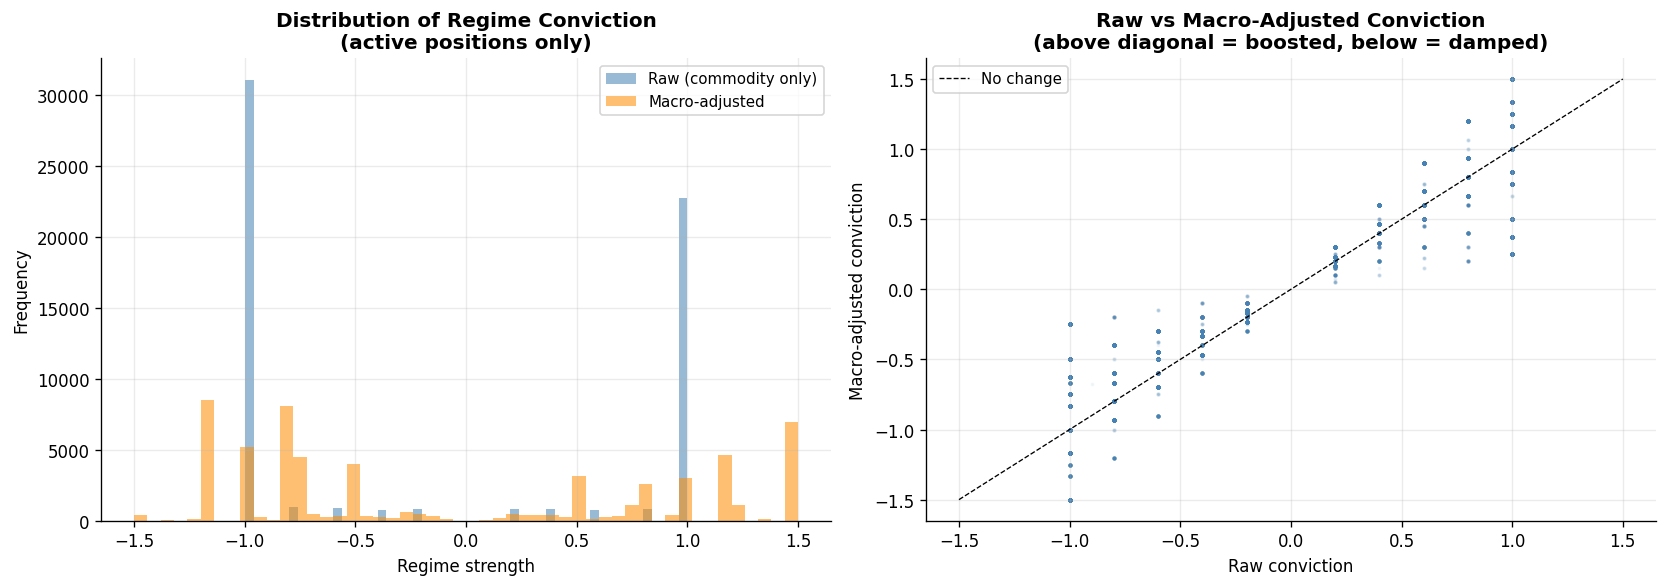

In [246]:
from signals.macro_signal import blend_regime_strength, apply_vol_cap
from signals.signal_layer1_enhanced import regime_strength as _raw_strength

# Raw commodity-only regime strength (no macro)
raw_strength = _raw_strength(prices,
                              fast=ENH_FILTER_FAST, slow=ENH_FILTER_SLOW)

# Macro-adjusted strength (same as used inside run_strategy_enh)
adj_strength = blend_regime_strength(raw_strength, m_score, alpha=ENH_MACRO_ALPHA)
adj_strength = apply_vol_cap(adj_strength, v_pct,
                             vol_cap_pct=ENH_VOL_CAP_PCT, vol_dampen=ENH_VOL_DAMPEN)

raw_flat = raw_strength.values.flatten()
adj_flat = adj_strength.values.flatten()
mask     = ~(np.isnan(raw_flat) | np.isnan(adj_flat) | (raw_flat == 0))

diff = adj_flat[mask] - raw_flat[mask]
pct_boosted = (diff > 0.01).mean() * 100
pct_damped  = (diff < -0.01).mean() * 100
pct_capped  = ((v_pct.reindex(prices.index) > ENH_VOL_CAP_PCT).fillna(False)).mean() * 100

print(f'Regime-active bars:  {mask.sum():,}')
print(f'  Boosted by macro : {pct_boosted:5.1f}%  (macro agreement → larger size)')
print(f'  Damped by macro  : {pct_damped:5.1f}%  (macro opposition → smaller size)')
print(f'  High-vol cap days: {pct_capped:5.1f}%  (EURUSD 3M ATM vol > {ENH_VOL_CAP_PCT:.0%} pct)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(raw_flat[mask], bins=50, alpha=0.55, color='steelblue',  label='Raw (commodity only)')
ax.hist(adj_flat[mask], bins=50, alpha=0.55, color='darkorange', label='Macro-adjusted')
ax.set_xlabel('Regime strength')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Regime Conviction\n(active positions only)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.scatter(raw_flat[mask], adj_flat[mask], alpha=0.05, s=2, color='steelblue')
lims = [min(raw_flat[mask].min(), adj_flat[mask].min()),
        max(raw_flat[mask].max(), adj_flat[mask].max())]
ax.plot(lims, lims, 'k--', lw=0.8, label='No change')
ax.set_xlabel('Raw conviction')
ax.set_ylabel('Macro-adjusted conviction')
ax.set_title('Raw vs Macro-Adjusted Conviction\n(above diagonal = boosted, below = damped)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()


## 5. Performance And Robustness
Compare Task 2 against the Task 1 baseline and the equal-weight factor using net returns after the configured transaction cost.

### 5.1 Summary Statistics
Report annualised return, volatility, Sharpe, drawdown, turnover, and trade counts.


In [247]:
stats_enh = pd.concat([
    performance_stats(port_r_enh, label=f'Enhanced Strategy Net ({ENH_TX_COST_BPS:g} bps)',
                      factor=factor, weights=wgt_enh, positions=pos_enh),
    performance_stats(port_r_enh_gross, label='Enhanced Strategy Gross (0 bps)',
                      factor=factor, weights=wgt_enh_gross, positions=pos_enh_gross),
    performance_stats(port_r, label='Baseline Strategy',
                      factor=factor, weights=weights, positions=positions),
    performance_stats(factor.reindex(port_r_enh.index).dropna(), label='EW Factor'),
], axis=1).T

stats_enh


,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Calmar,Max DD %,Skewness,Hit Rate,Num Trades,Trades / Year,Ann. Turnover %,Alpha (ann) %,Beta,R²
Enhanced Strategy Net (2 bps),4.68,10.92,0.428,0.524,0.227,-20.58,0.143,0.418,1028.0,69.7,1210.0,4.57,0.085,0.015
Enhanced Strategy Gross (0 bps),4.92,10.92,0.450,0.547,0.241,-20.41,0.146,0.419,1028.0,69.7,1210.0,4.82,0.085,0.015
Baseline Strategy,1.78,15.98,0.111,0.139,0.040,-44.36,-0.434,0.456,955.0,64.8,1230.9,1.87,-0.074,0.005
EW Factor,1.23,15.65,0.078,0.106,0.023,-52.91,-0.217,0.508,NaN,NaN,NaN,NaN,NaN,NaN


### 5.2 Transaction Cost Sensitivity
Re-run the enhanced strategy on training data under different one-way transaction-cost assumptions.


In [248]:
tc_sensitivity = transaction_cost_sensitivity(
    prices,
    returns,
    cost_bps=(0.0, 2.0, 5.0, 10.0),
    strategy_kwargs=enhanced_kwargs,
)

tc_display = tc_sensitivity.copy()
for col in ['ann_return_net', 'ann_vol_net', 'max_drawdown', 'ann_turnover',
            'ann_return_gross', 'ann_cost', 'long_contribution_ann', 'short_contribution_ann']:
    if col in tc_display:
        tc_display[col] = (tc_display[col] * 100).round(2)
for col in ['sharpe_net', 'sharpe_gross']:
    if col in tc_display:
        tc_display[col] = tc_display[col].round(3)

display(tc_display)


,ann_return_net,ann_vol_net,sharpe_net,max_drawdown,entries,short_entries,ann_turnover,tx_cost_bps,sharpe_gross,ann_return_gross,ann_cost,long_contribution_ann,short_contribution_ann
cost_bps,,,,,,,,,,,,,
0.0,4.92,10.92,0.450,-20.41,1028,370,1209.96,0.0,0.45,4.92,0.00,3.7,1.22
2.0,4.68,10.92,0.428,-20.58,1028,370,1209.96,2.0,0.45,4.92,0.24,3.7,1.22
5.0,4.31,10.92,0.395,-20.84,1028,370,1209.96,5.0,0.45,4.92,0.60,3.7,1.22
10.0,3.71,10.92,0.340,-22.28,1028,370,1209.96,10.0,0.45,4.92,1.21,3.7,1.22


### 5.3 SL Multiplier Training Grid
Run the predefined training-only `sl_mult` sizing grid. This diagnostic changes only the portfolio sizing stop-distance assumption; SAR exits, RSI filters, macro settings, and transaction costs stay fixed.


In [249]:
sl_mult_grid_results = sl_mult_grid_search(
    prices,
    returns,
    strategy_kwargs=enhanced_kwargs,
    tx_cost_bps=ENH_TX_COST_BPS,
)

sl_mult_grid_path = Path('sl_mult_grid_results.csv')
sl_mult_grid_results.to_csv(sl_mult_grid_path, index=False)

sl_cols = [
    'passes_basic_filter', 'sharpe_net', 'sharpe_gross', 'max_drawdown',
    'entries', 'short_entries', 'ann_turnover', 'ann_cost',
    'long_contribution_ann', 'short_contribution_ann', 'sl_mult',
    'baseline_sharpe_net', 'baseline_max_drawdown', 'baseline_entries',
    'baseline_ann_turnover', 'baseline_ann_cost',
]

display(sl_mult_grid_results[sl_cols])
print(f'Saved full SL multiplier grid to {sl_mult_grid_path}')


,passes_basic_filter,sharpe_net,sharpe_gross,max_drawdown,entries,short_entries,ann_turnover,ann_cost,long_contribution_ann,short_contribution_ann,sl_mult,baseline_sharpe_net,baseline_max_drawdown,baseline_entries,baseline_ann_turnover,baseline_ann_cost
0,True,0.428202,0.450314,-0.205832,1028,370,12.099556,0.002420,0.037005,0.012184,3.0,0.428202,-0.205832,1028,12.099556,0.00242
1,True,0.427416,0.449754,-0.195050,1028,370,11.636779,0.002327,0.036111,0.010658,3.5,0.428202,-0.205832,1028,12.099556,0.00242
2,True,0.421132,0.443753,-0.195878,1028,370,11.141968,0.002228,0.034545,0.009089,4.0,0.428202,-0.205832,1028,12.099556,0.00242
3,True,0.418419,0.441311,-0.193061,1028,370,10.645316,0.002129,0.033431,0.007543,4.5,0.428202,-0.205832,1028,12.099556,0.00242
4,True,0.418056,0.439973,-0.238081,1028,370,12.558841,0.002512,0.038080,0.012255,2.5,0.428202,-0.205832,1028,12.099556,0.00242
5,True,0.411548,0.434703,-0.189906,1028,370,10.156466,0.002031,0.032119,0.005956,5.0,0.428202,-0.205832,1028,12.099556,0.00242
6,False,0.378638,0.400321,-0.281659,1028,370,13.018327,0.002604,0.038890,0.009109,2.0,0.428202,-0.205832,1028,12.099556,0.00242
7,False,0.341339,0.362713,-0.332779,1028,370,13.453340,0.002691,0.039584,0.006018,1.5,0.428202,-0.205832,1028,12.099556,0.00242


Saved full SL multiplier grid to sl_mult_grid_results.csv


### 5.4 SAR Training Grid
Run the predefined training-only SAR grid. This diagnostic ranks candidates by net Sharpe and robustness filters, but the top row is not automatically the final choice.


In [250]:
sar_grid_results = sar_grid_search(
    prices,
    returns,
    strategy_kwargs=enhanced_kwargs,
    tx_cost_bps=ENH_TX_COST_BPS,
)

sar_grid_path = Path('sar_grid_results.csv')
sar_grid_results.to_csv(sar_grid_path, index=False)

sar_cols = [
    'passes_basic_filter', 'sharpe_net', 'sharpe_gross', 'max_drawdown',
    'entries', 'short_entries', 'ann_turnover', 'ann_cost',
    'sar_initial_mult', 'sar_af_start', 'sar_af_step', 'sar_af_max', 'sar_grace_period',
    'baseline_sharpe_net', 'baseline_max_drawdown', 'baseline_entries',
]

display(sar_grid_results[sar_cols].head(20))
print(f'Saved full SAR grid to {sar_grid_path}')


KeyboardInterrupt: 

### 5.5 Rolling Sharpe
Print full-period Sharpe sanity checks, then plot one-year rolling Sharpe on a common date index.


In [ ]:
def _full_period_sharpe(r):
    r = r.dropna()
    return (r.mean() * 252) / (r.std() * np.sqrt(252))

enh_short_entries = int(((pos_enh == -1) & (pos_enh.shift(1).fillna(0) == 0)).sum().sum())

print(f"Enhanced net full-period Sharpe   : {_full_period_sharpe(port_r_enh):.3f}  ({ENH_TX_COST_BPS:g} bps)")
print(f"Enhanced gross full-period Sharpe : {_full_period_sharpe(port_r_enh_gross):.3f}  (0 bps)")
print(f"Baseline full-period Sharpe       : {_full_period_sharpe(port_r.reindex(port_r_enh.index)):.3f}")
print(f"EW Factor full-period Sharpe      : {_full_period_sharpe(factor.reindex(port_r_enh.index)):.3f}")
print(f"Enhanced short entries            : {enh_short_entries}")

rolling_sharpe_df = plot_rolling_sharpe(
    {'Enhanced Strategy Net': port_r_enh,
     'Enhanced Strategy Gross': port_r_enh_gross.reindex(port_r_enh.index),
     'Baseline Strategy': port_r.reindex(port_r_enh.index),
     'EW Factor': factor.reindex(port_r_enh.index)},
    window=252,
)


### 5.6 Cumulative Returns
Plot log cumulative returns for enhanced Task 2, Task 1 baseline, and the equal-weight commodity factor.


In [ ]:
cum_enh    = (1 + port_r_enh.dropna()).cumprod()
cum_base   = (1 + port_r.reindex(port_r_enh.index).dropna()).cumprod()
cum_factor = (1 + factor.reindex(port_r_enh.index).dropna()).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum_enh.index,    cum_enh.values,    color='steelblue',  lw=2.0, label='Enhanced Strategy')
ax.plot(cum_base.index,   cum_base.values,   color='darkorange', lw=1.5, linestyle='--', label='Baseline Strategy')
ax.plot(cum_factor.index, cum_factor.values, color='black',      lw=1.2, linestyle=':',  label='EW Factor')
ax.axhline(1, color='grey', lw=0.5)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_title('Cumulative Return — Enhanced vs Baseline vs EW Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (log scale)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


### 5.7 Sector Contribution
Break enhanced returns into sector-level contribution and show final position exposure.


In [ ]:
sc_enh = sector_contribution(wgt_enh, returns, assets)

sc_enh_summary = pd.DataFrame({
    'Ann. Contribution %' : (sc_enh.mean() * 252 * 100).round(2),
    'Ann. Vol %'          : (sc_enh.std()  * np.sqrt(252) * 100).round(2),
    'Sharpe'              : ((sc_enh.mean() * 252) / (sc_enh.std() * np.sqrt(252))).round(3),
})
display(sc_enh_summary)

sector_colours = {'Agri & livestock': '#2e8b57', 'Energy': '#cc4400', 'Metals': '#4169e1'}
fig, ax = plt.subplots(figsize=(13, 4))
for col in sc_enh.cumsum().columns:
    ax.plot(sc_enh.cumsum().index, sc_enh.cumsum()[col],
            color=sector_colours.get(col, 'grey'), lw=1.8, label=col)
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Cumulative Return Contribution by Sector (Enhanced)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 6. Final Summary Notes
Task 2 keeps the Task 1 trend-following identity while adding enhanced conviction, macro sizing, execution-time short RSI filtering, Parabolic SAR exits, and transaction costs. All tuning diagnostics in this notebook are training-only. Freeze selected parameters before running any final holdout evaluation.
